<a href="https://colab.research.google.com/github/leojroliveira/Analise_DEA_RPPS/blob/main/Analise_DEA_RPPS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Análise da eficiência relativa dos Regimes Próprios de Previdência Social (RPPS) por meio da DEA
Este notebook tem como objetivo o tratamento, a análise e a aplicação da Análise Envoltória de Dados (DEA) sobre as bases de dados do Índice de Situação Previdenciária (ISP) e do Demonstrativo de Informações Previdenciárias e Repasses (DIPR) com foco na avaliação dos impactos da Certificação Pró-Gestão nos Regimes Próprios de Previdência Social (RPPS). Serão utilizados dados do período de 2018 a 2023, com o intuito de analisar a evolução temporal da eficiência dos RPPS certificados em comparação aos não certificados.

*This notebook aims to process, analyze, and apply Data Envelopment Analysis (DEA) to a dataset, focusing on assessing the impacts of the Pró-Gestão Certification on the Public Pension Schemes (RPPS). Data from the period 2018 to 2023 will be used to evaluate the temporal evolution of efficiency in certified RPPS compared to non-certified ones.*

#Importação de bibliotecas e bases de dados

In [ ]:
# Importar as bibliotecas que serão utilizadas no modelo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata
import os
import plotly.express as px
from scipy.stats import wilcoxon, mannwhitneyu
from IPython.display import display, HTML
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from google.colab import files
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
# Clonar os dados do repositório no Github
!git clone https://github.com/leojroliveira/Analise_DEA_RPPS.git
%cd Analise_DEA_RPPS
!ls

Cloning into 'Analise_DEA_RPPS'...
remote: Enumerating objects: 159, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 159 (delta 30), reused 15 (delta 15), pack-reused 121 (from 2)
Receiving objects: 100% (159/159), 81.84 MiB | 11.75 MiB/s, done.
Resolving deltas: 100% (61/61), done.
Updating files: 100% (13/13), done.
/content/Analise_DEA_RPPS
DIPR2018_RG_OUTROS_DP_ENVIO_20250226.xlsx
DIPR2019_RG_OUTROS_DP_ENVIO_20250226.xlsx
DIPR2020_RG_OUTROS_DP_ENVIO_20250226.xlsx
DIPR2021_RG_OUTROS_DP_ENVIO_20250226.xlsx
DIPR2022_RG_OUTROS_DP_ENVIO_20250226.xlsx
DIPR2023_RG_OUTROS_DP_ENVIO_20250407.xlsx
ISP2019_Resultado_Final_Consolidado.xlsx
ISP2020_Resultado_Final_Consolidado.xlsx
ISP2021_Resultado_Final_Consolidado.xlsx
ISP2022_Resultado_Final_Consolidado.xlsx
ISP2023_Resultado_Final_Consolidado.xlsx
ISP2024_Resultado_Final_Consolidado.xlsx
Pro_Gestao_Entes_Certificados_20250324.xlsx


#Leitura, limpeza e padronização dos dados

In [ ]:
# Função para remover acentos nas bases, é chamada em várias outras funções de limpeza
def remover_acentos(texto):
    if isinstance(texto, str):
        return unicodedata.normalize('NFKD', texto).encode('ASCII', 'ignore').decode('utf-8')
    return texto

In [ ]:
# Função para tratar os arquivos DIPR
def tratar_DIPR(arquivo):
    # Definir colunas relevantes
    colunas_para_ler = [0, 1, 2, 3, 4, 42, 43, 44, 46, 47, 51, 52, 53, 55, 56, 63]

    # Carregar a partir da linha 5
    df = pd.read_excel(
        arquivo,
        skiprows=4,
        usecols=colunas_para_ler,
        engine='openpyxl',
        decimal=',',
        thousands='.'
    )

    # Resetar índice
    df.reset_index(drop=True, inplace=True)

    # Renomear colunas
    df.columns = [
        'ente',
        'uf',
        'competencia',
        'tipo_plano',
        'data_informacao',
        'quant_ativos',
        'quant_aposentados',
        'quant_pensionistas',
        'contrib_previdenciaria',
        'aportes',
        'receita_comprev',
        'receita_liquida_investimentos',
        'rendimento_demais_ativos',
        'pagamento_aposentadorias',
        'pagamento_pensoes',
        'custo_administrativo'
    ]

    # Padronizar nome do ente e remover acentos
    df['ente'] = df['ente'].astype(str).str.strip().str.upper()
    df['ente'] = df['ente'].apply(remover_acentos)

    # Inserir sufixo (ESTADO) para os entes estaduais homônimos
    df['ente'] = df.apply(
        lambda row: f"{row['ente']} (ESTADO)" if (
            'GOVERNO DO ESTADO' in row['ente'] and
            any(estado in row['ente'] for estado in ['SAO PAULO', 'RIO DE JANEIRO'])
        ) else row['ente'],
        axis=1
    )

    # Limpar prefixos e padronizar nome
    df['ente'] = df['ente'].str.replace(
        r'^(GOVERNO DO ESTADO|PREFEITURA MUNICIPAL)\s+(DE|DA|DO)\s+', '',
        regex=True
    ).str.strip().str.title()

    # Corrigir preposições
    df['ente'] = df['ente'].str.replace(r'\b(Da|De|Do|Das|Dos)\b', lambda x: x.group(0).lower(), regex=True)

    df['competencia'] = df['competencia'].astype(str).str.strip().str.upper()

    # Filtrar apenas Financeiro e Previdenciário
    df = df[df['tipo_plano'].str.upper().isin(['PREVIDENCIÁRIO', 'FINANCEIRO'])]

    # Tratar tipos de dados quantitativos como numéricos
    df['quant_ativos'] = pd.to_numeric(df['quant_ativos'], errors='coerce')
    df['quant_aposentados'] = pd.to_numeric(df['quant_aposentados'], errors='coerce')
    df['quant_pensionistas'] = pd.to_numeric(df['quant_pensionistas'], errors='coerce')
    df['contrib_previdenciaria'] = pd.to_numeric(df['contrib_previdenciaria'], errors='coerce')
    df['aportes'] = pd.to_numeric(df['aportes'], errors='coerce')
    df['receita_comprev'] = pd.to_numeric(df['receita_comprev'], errors='coerce')
    df['receita_liquida_investimentos'] = pd.to_numeric(df['receita_liquida_investimentos'], errors='coerce')
    df['rendimento_demais_ativos'] = pd.to_numeric(df['rendimento_demais_ativos'], errors='coerce')
    df['pagamento_aposentadorias'] = pd.to_numeric(df['pagamento_aposentadorias'], errors='coerce')
    df['pagamento_pensoes'] = pd.to_numeric(df['pagamento_pensoes'], errors='coerce')
    df['custo_administrativo'] = pd.to_numeric(df['custo_administrativo'], errors='coerce')


    # Consolidar por ente + uf + competencia
    df_competencia = df.groupby(['ente', 'uf', 'competencia']).agg({
        'quant_ativos': 'sum',
        'quant_aposentados': 'sum',
        'quant_pensionistas': 'sum',
        'contrib_previdenciaria': 'sum',
        'aportes': 'sum',
        'receita_comprev': 'sum',
        'receita_liquida_investimentos': 'sum',
        'rendimento_demais_ativos': 'sum',
        'pagamento_aposentadorias': 'sum',
        'pagamento_pensoes': 'sum',
        'custo_administrativo': 'sum'

    }).reset_index()

    # Extrair o ano
    df_competencia['ano'] = df_competencia['competencia'].str[-4:].astype(int)

    # Agregar final por ente e ano
    df_aggregado = df_competencia.groupby(['ente', 'uf', 'ano']).agg({
        'quant_ativos': 'mean',
        'quant_aposentados': 'mean',
        'quant_pensionistas': 'mean',
        'contrib_previdenciaria': 'sum',
        'aportes': 'sum',
        'receita_comprev': 'sum',
        'receita_liquida_investimentos': 'sum',
        'rendimento_demais_ativos': 'sum',
        'pagamento_aposentadorias': 'sum',
        'pagamento_pensoes': 'sum',
        'custo_administrativo': 'sum'
    }).reset_index()

    # Formatar resultados
    df_aggregado['quant_ativos'] = df_aggregado['quant_ativos'].round(0).astype(int)
    df_aggregado['quant_aposentados'] = df_aggregado['quant_aposentados'].round(0).astype(int)
    df_aggregado['quant_pensionistas'] = df_aggregado['quant_pensionistas'].round(0).astype(int)
    for col in ['contrib_previdenciaria', 'aportes', 'receita_comprev', 'receita_liquida_investimentos',
                'rendimento_demais_ativos', 'pagamento_aposentadorias', 'pagamento_pensoes', 'custo_administrativo']:
        df_aggregado[col] = df_aggregado[col].round(2)

    return df_aggregado

In [ ]:
# Função para primeira fase de tratamento dos arquivos ISP. Extrai a variável de um arquivo ISP
def tratar_ISP_variavel(arquivo_path, variavel, ano, aba_idx, col_idx, linha):

    linha_header = linha

    # Ler a aba e linha de cabeçalho
    df = pd.read_excel(
        arquivo_path,
        sheet_name=aba_idx,
        header=linha,
        engine='openpyxl'
    )

    # Selecionar as colunas necessárias (ente + valor)
    df = df.iloc[:, [0, col_idx]]
    df.columns = ['ente_bruto', 'valor']

    # Tratar ente bruto e extrair UF
    df['ente_bruto'] = df['ente_bruto'].astype(str).str.strip().str.upper()
    df['uf'] = df['ente_bruto'].str.extract(r'-\s*([A-Z]{2})$', expand=False).str.upper()

    # Marcar como (ESTADO) nos casos estaduais homônimos
    df['ente_bruto'] = df.apply(
        lambda row: f"{row['ente_bruto']} (ESTADO)" if (
            'GOVERNO DO ESTADO' in row['ente_bruto'] and
            any(estado in row['ente_bruto'] for estado in ['SAO PAULO', 'RIO DE JANEIRO'])
        ) else row['ente_bruto'],
        axis=1
    )

    # Limpar prefixos e padronizar nome do ente
    df['ente'] = df['ente_bruto'].str.replace(
        r'^(GOVERNO DO ESTADO|PREFEITURA MUNICIPAL)\s+(DE|DA|DO)\s+', '',
        regex=True
    ).str.replace(r'-\s*[A-Z]{2}\s*(\(ESTADO\))?$', '', regex=True).str.strip().str.title()

    # Corrigir preposições e remover acentos
    df['ente'] = df['ente'].str.replace(r'\b(Da|De|Do|Das|Dos)\b', lambda x: x.group(0).lower(), regex=True)
    df['ente'] = df['ente'].apply(remover_acentos)

    # Reaplicar sufixo (ESTADO) se necessário
    df['ente'] = df.apply(
        lambda row: f"{row['ente']} (ESTADO)" if '(ESTADO)' in row['ente_bruto'] else row['ente'],
        axis=1
    )

    # Adicionar metadados
    df['ano'] = ano
    df['variavel'] = variavel

    return df[['ente', 'uf', 'ano', 'variavel', 'valor']]

In [ ]:
# Função para segunda fase de tratamento dos arquivos ISP. Trata e agrupa as variáveis em um DataFrame.
def tratar_ISP_ano(arquivo, ano, parametros, base_path='./'):
    resultados = []

    for variavel, config in parametros.items():
        try:
            df_temp = tratar_ISP_variavel(
                arquivo_path=f"{base_path}{arquivo}",
                variavel=variavel,
                ano=ano,
                aba_idx=config['aba_idx'],
                col_idx=config['col_idx'],
                linha=config['linha'],
            ).copy()

            # Tratar valores numéricos, exceto variáveis categóricas
            if variavel.lower() not in ['grupo']:
                df_temp['valor'] = (
                    df_temp['valor']
                    .astype(str)
                    .str.strip()
                    .replace('-', pd.NA)
                )
                df_temp['valor'] = pd.to_numeric(df_temp['valor'], errors='coerce')

            resultados.append(df_temp)

        except Exception as e:
            print(f"Erro ao tratar {variavel} ({ano}): {e}")

    # Concatenar todas as variáveis tratadas
    df_long = pd.concat(resultados, ignore_index=True)

    # Padronizar campos de texto
    for df in [df_long]:
        df['ente'] = df['ente'].astype(str).str.strip().str.upper().apply(remover_acentos)
        df['uf'] = df['uf'].astype(str).str.strip().str.upper()

    df_long['ano'] = df_long['ano'].astype(int)

    # Converter para formato wide
    df_wide = df_long.pivot_table(
        index=['ente', 'uf', 'ano'],
        columns='variavel',
        values='valor',
        aggfunc='first'
    ).reset_index()

    # Ordenar colunas
    variaveis_ordenadas = ['ente', 'uf', 'ano'] + list(parametros.keys())
    df_wide = df_wide[variaveis_ordenadas]

    # Tratamento adicional para variáveis numéricas
    for col in df_wide.columns:
        if col not in ['ente', 'uf', 'ano', 'grupo']:
            df_wide[col] = pd.to_numeric(df_wide[col], errors='coerce')

    return df_wide


In [ ]:
# Função para tratar o arquivo de entes certificados no Pró-Gestão
def tratar_Pro_Gestao(arquivo):

    # Carregar todas as colunas
    df = pd.read_excel(arquivo, engine='openpyxl')

    # Excluir a primeira coluna (índice 0) e a primeira linha
    df = df.iloc[:, 1:]
    df = df.iloc[1:, :].reset_index(drop=True)

    # Renomear colunas
    df.columns = [
        'cnpj', 'ente', 'uf', 'data_recebimento_adesao', 'data_adesao',
        'data_cert_inicial', 'nivel_inicial', 'data_renovacao_cert', 'nivel_atual'
    ]

    # Reordenar colunas
    colunas_ordenadas = ['ente', 'uf', 'cnpj', 'data_recebimento_adesao', 'data_adesao',
                         'data_cert_inicial', 'nivel_inicial', 'data_renovacao_cert', 'nivel_atual']
    df = df[colunas_ordenadas]

    # Criar coluna temporária para preservar o nome original
    df['ente_original'] = df['ente'].astype(str).str.strip().str.upper()

    # Criar versão sem acento para comparação
    df['ente_normalizado'] = df['ente_original'].apply(remover_acentos)

    # Padronizar nome do ente
    df['ente'] = df['ente_original']

    # Limpar prefixos e padronizar nome do ente
    df['ente'] = df['ente'].str.replace(
        r'^(GOVERNO DO ESTADO|PREFEITURA MUNICIPAL)\s+(DE|DA|DO)\s+', '',
        regex=True
    ).str.strip().str.title()

    # Corrigir preposições e remover acentos
    df['ente'] = df['ente'].str.replace(r'\b(Da|De|Do|Das|Dos)\b', lambda x: x.group(0).lower(), regex=True)
    df['ente'] = df['ente'].apply(remover_acentos)

    # Marcar como (ESTADO) nos casos estaduais homônimos
    df['ente'] = df.apply(
        lambda row: f"{row['ente']} (ESTADO)" if (
            'GOVERNO DO ESTADO' in row['ente_normalizado'] and
            any(estado in row['ente_normalizado'] for estado in ['SAO PAULO', 'RIO DE JANEIRO'])
        ) else row['ente'],
        axis=1
    )

    # Remover colunas temporárias
    df = df.drop(columns=['ente_original', 'ente_normalizado'])

    # Padronizar e preservar valores ausentes em 'nivel_inicial' e 'nivel_atual'
    for col in ['nivel_inicial', 'nivel_atual']:
      df[col] = df[col].replace(['', 'NaN', 'nan', 'NAN', 'None'], np.nan)
      df[col] = df[col].apply(lambda x: str(x).strip().upper() if pd.notnull(x) else np.nan)

    return df

In [ ]:
# Chamada para rodar o tratamento dos arquivos DIPR
df_DIPR_2018 = tratar_DIPR('DIPR2018_RG_OUTROS_DP_ENVIO_20250226.xlsx')
df_DIPR_2019 = tratar_DIPR('DIPR2019_RG_OUTROS_DP_ENVIO_20250226.xlsx')
df_DIPR_2020 = tratar_DIPR('DIPR2020_RG_OUTROS_DP_ENVIO_20250226.xlsx')
df_DIPR_2021 = tratar_DIPR('DIPR2021_RG_OUTROS_DP_ENVIO_20250226.xlsx')
df_DIPR_2022 = tratar_DIPR('DIPR2022_RG_OUTROS_DP_ENVIO_20250226.xlsx')
df_DIPR_2023 = tratar_DIPR('DIPR2023_RG_OUTROS_DP_ENVIO_20250407.xlsx')

/usr/local/lib/python3.11/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.11/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.11/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.11/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.11/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default sty

In [ ]:
# Chamada para rodar o tratamento dos arquivos ISP
df_ISP_2018 = tratar_ISP_ano(
    arquivo='ISP2019_Resultado_Final_Consolidado.xlsx',
    ano=2018,
    parametros={
        'suficiencia_financeira': {'aba_idx': 10, 'col_idx': 14, 'linha': 2},
        'recursos_acumulados': {'aba_idx': 12, 'col_idx': 6, 'linha': 2},
        'provisoes_matematicas': {'aba_idx': 14, 'col_idx': 16, 'linha': 2},
        'cobertura_previdenciaria': {'aba_idx': 14, 'col_idx': 17, 'linha': 2},
        'grupo': {'aba_idx': 14, 'col_idx': 3, 'linha': 2}
    }
)
df_ISP_2019 = tratar_ISP_ano(
    arquivo='ISP2020_Resultado_Final_Consolidado.xlsx',
    ano=2019,
    parametros={
        'suficiencia_financeira': {'aba_idx': 6, 'col_idx': 12, 'linha': 0},
        'recursos_acumulados': {'aba_idx': 7, 'col_idx': 4, 'linha': 0},
        'provisoes_matematicas': {'aba_idx': 8, 'col_idx': 11, 'linha': 0},
        'cobertura_previdenciaria': {'aba_idx': 8, 'col_idx': 12, 'linha': 0},
        'grupo': {'aba_idx': 8, 'col_idx': 1, 'linha': 0}
    }
)
df_ISP_2020 = tratar_ISP_ano(
    arquivo='ISP2021_Resultado_Final_Consolidado.xlsx',
    ano=2020,
    parametros={
        'suficiencia_financeira': {'aba_idx': 6, 'col_idx': 12, 'linha': 0},
        'recursos_acumulados': {'aba_idx': 7, 'col_idx': 4, 'linha': 0},
        'provisoes_matematicas': {'aba_idx': 8, 'col_idx': 10, 'linha': 0},
        'cobertura_previdenciaria': {'aba_idx': 8, 'col_idx': 11, 'linha': 0},
        'grupo': {'aba_idx': 8, 'col_idx': 1, 'linha': 0}
    }
)
df_ISP_2021 = tratar_ISP_ano(
    arquivo='ISP2022_Resultado_Final_Consolidado.xlsx',
    ano=2021,
    parametros={
        'suficiencia_financeira': {'aba_idx': 6, 'col_idx': 15, 'linha': 0},
        'recursos_acumulados': {'aba_idx': 7, 'col_idx': 7, 'linha': 0},
        'provisoes_matematicas': {'aba_idx': 8, 'col_idx': 13, 'linha': 0},
        'cobertura_previdenciaria': {'aba_idx': 8, 'col_idx': 14, 'linha': 0},
        'grupo': {'aba_idx': 8, 'col_idx': 3, 'linha': 0}
    }
)
df_ISP_2022 = tratar_ISP_ano(
    arquivo='ISP2023_Resultado_Final_Consolidado.xlsx',
    ano=2022,
    parametros={
        'suficiencia_financeira': {'aba_idx': 6, 'col_idx': 14, 'linha': 1},
        'recursos_acumulados': {'aba_idx': 7, 'col_idx': 6, 'linha': 1},
        'provisoes_matematicas': {'aba_idx': 8, 'col_idx': 12, 'linha': 1},
        'cobertura_previdenciaria': {'aba_idx': 8, 'col_idx': 13, 'linha': 1},
        'grupo': {'aba_idx': 8, 'col_idx': 3, 'linha': 1}
    }
)
df_ISP_2023 = tratar_ISP_ano(
    arquivo='ISP2024_Resultado_Final_Consolidado.xlsx',
    ano=2023,
    parametros={
        'suficiencia_financeira': {'aba_idx': 6, 'col_idx': 14, 'linha': 3},
        'recursos_acumulados': {'aba_idx': 7, 'col_idx': 6, 'linha': 3},
        'provisoes_matematicas': {'aba_idx': 8, 'col_idx': 13, 'linha': 3},
        'cobertura_previdenciaria': {'aba_idx': 8, 'col_idx': 14, 'linha': 3},
        'grupo': {'aba_idx': 8, 'col_idx': 3, 'linha': 3}
    }
)

/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/_reader.py:

In [ ]:
# Chamada para rodar o tratamento do arquivo Pro-gestão com os entes certificados.
df_PRO_GESTAO = tratar_Pro_Gestao('Pro_Gestao_Entes_Certificados_20250324.xlsx')

In [ ]:
# Unifica os dados de todos os anos do DIPR, ISP e do Pro-Gestão, padroniza campos (ente, uf, ano, recursos_acumulados) e remove acentos
df_DIPR = pd.concat([df_DIPR_2018, df_DIPR_2019, df_DIPR_2020, df_DIPR_2021,
                     df_DIPR_2022, df_DIPR_2023], ignore_index=True)

df_ISP = pd.concat([df_ISP_2018, df_ISP_2019, df_ISP_2020, df_ISP_2021,
                    df_ISP_2022, df_ISP_2023], ignore_index=True)

# Tratar a variável recursos acumulados e provisoes_matematicas do ISP como numérico
df_ISP['recursos_acumulados'] = pd.to_numeric(df_ISP['recursos_acumulados'], errors='coerce')
df_ISP['provisoes_matematicas'] = pd.to_numeric(df_ISP['provisoes_matematicas'], errors='coerce')

# Padroniza os nomes dos entes nos três arquivos antes de juntar
for df in [df_DIPR, df_ISP, df_PRO_GESTAO]:
    df['ente'] = df['ente'].astype(str).str.strip().str.upper().apply(remover_acentos)
    df['uf'] = df['uf'].astype(str).str.strip().str.upper()

df_DIPR['ano'] = df_DIPR['ano'].astype(int)
df_ISP['ano'] = df_ISP['ano'].astype(int)

# Merge entre DIPR e ISP (por ente, uf, ano) e depois com o Pró-Gestão (por ente e uf)
df_DIPR_ISP = pd.merge(df_DIPR, df_ISP, on=['ente', 'uf', 'ano'], how='left')

# Merge com Pró-Gestão (dados estáticos inseridos apenas no ano de 2023)
df_pro_gestao_2023 = df_PRO_GESTAO.copy()
df_pro_gestao_2023['ano'] = 2023

df_integrado = pd.merge(df_DIPR_ISP, df_pro_gestao_2023, on=['ente', 'uf', 'ano'], how='left')

print("Estrutura do dataset Integrado:")
print(df_integrado.info())

# Baixar dados em Excel
#df_integrado.to_excel('df_integrado.xlsx', index=False)
#files.download('df_integrado.xlsx')

Estrutura do dataset Integrado:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12821 entries, 0 to 12820
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ente                           12821 non-null  object 
 1   uf                             12821 non-null  object 
 2   ano                            12821 non-null  int64  
 3   quant_ativos                   12821 non-null  int64  
 4   quant_aposentados              12821 non-null  int64  
 5   quant_pensionistas             12821 non-null  int64  
 6   contrib_previdenciaria         12821 non-null  float64
 7   aportes                        12821 non-null  float64
 8   receita_comprev                12821 non-null  float64
 9   receita_liquida_investimentos  12821 non-null  float64
 10  rendimento_demais_ativos       12821 non-null  float64
 11  pagamento_aposentadorias       12821 non-null  float64
 12  pagamento_pens

#Seleção de variáveis e parâmetros

In [ ]:
# Célula para agregar variáveis e selecionar os campos que serão utilizados no modelo. Define também os valores do IQR e Z Score para detecção de ouliers

# Variáveis derivadas
df_integrado['quant_segurados'] = df_integrado['quant_aposentados'] + df_integrado['quant_pensionistas'] + df_integrado['quant_ativos']
df_integrado['resultado_investimentos'] = df_integrado['receita_liquida_investimentos'] + df_integrado['rendimento_demais_ativos']
df_integrado['receita_previdenciaria'] = df_integrado['contrib_previdenciaria'] + df_integrado['receita_comprev']
df_integrado['pagamento_beneficios'] = df_integrado['pagamento_aposentadorias'] + df_integrado['pagamento_pensoes']

# Definições de grupos de variáveis
variaveis_id = ['ente', 'uf', 'ano', 'cnpj']
variaveis_progestao = ['grupo', 'data_cert_inicial', 'nivel_inicial']
inputs_dea = ['quant_segurados', 'custo_administrativo']
outputs_dea = ['receita_previdenciaria','recursos_acumulados', 'resultado_investimentos']
variaveis_utilizadas = variaveis_id + inputs_dea + outputs_dea + variaveis_progestao

# DataFrame final
df_modelo = df_integrado[variaveis_utilizadas].copy()

# Parâmetros de detecção de outliers
iqr_inferior = 1.5
iqr_superior = 1.5
z_score = 2.0
calibre_psm = 0.05
variaveis_psm = inputs_dea + outputs_dea

# Definição do período conforme data de certificação
DataCertInicial = 2018
DataCertFinal = 2023

# contagem de variáveis
n_inputs = len(inputs_dea)
n_outputs = len(outputs_dea)

# Envia variáveis de contagem de inputs e outputs para o ambiente R
%load_ext rpy2.ipython
%R -i n_inputs -i n_outputs


#1ª Verificação da distribuição dos dados

In [ ]:
# Função para verificar distribuição dos dados
def plot_distribuicoes(df, variaveis):

    sns.set(style="whitegrid")

    num_vars = len(variaveis)
    fig, axes = plt.subplots(num_vars, 4, figsize=(20, 5 * num_vars))

    for i, var in enumerate(variaveis):
        dados_milhoes = df[var] / 1_000_000
        dados_log = np.log1p(dados_milhoes)

        # Histograma original
        sns.histplot(dados_milhoes, bins=30, kde=True, ax=axes[i, 0], color='skyblue')
        axes[i, 0].set_title(f'Histograma - {var} (milhões)')
        axes[i, 0].set_xlabel(f"{var}")

        # Boxplot original
        sns.boxplot(x=dados_milhoes, ax=axes[i, 1], color='lightcoral')
        axes[i, 1].set_title(f'Boxplot - {var} (milhões)')

        # Histograma log
        sns.histplot(dados_log, bins=30, kde=True, ax=axes[i, 2], color='skyblue')
        axes[i, 2].set_title(f'Histograma log1p - {var}')
        axes[i, 2].set_xlabel(f"log({var})")

        # Boxplot log
        sns.boxplot(x=dados_log, ax=axes[i, 3], color='lightcoral')
        axes[i, 3].set_title(f'Boxplot log1p - {var}')

    plt.tight_layout(h_pad=4.0)
    plt.show()

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


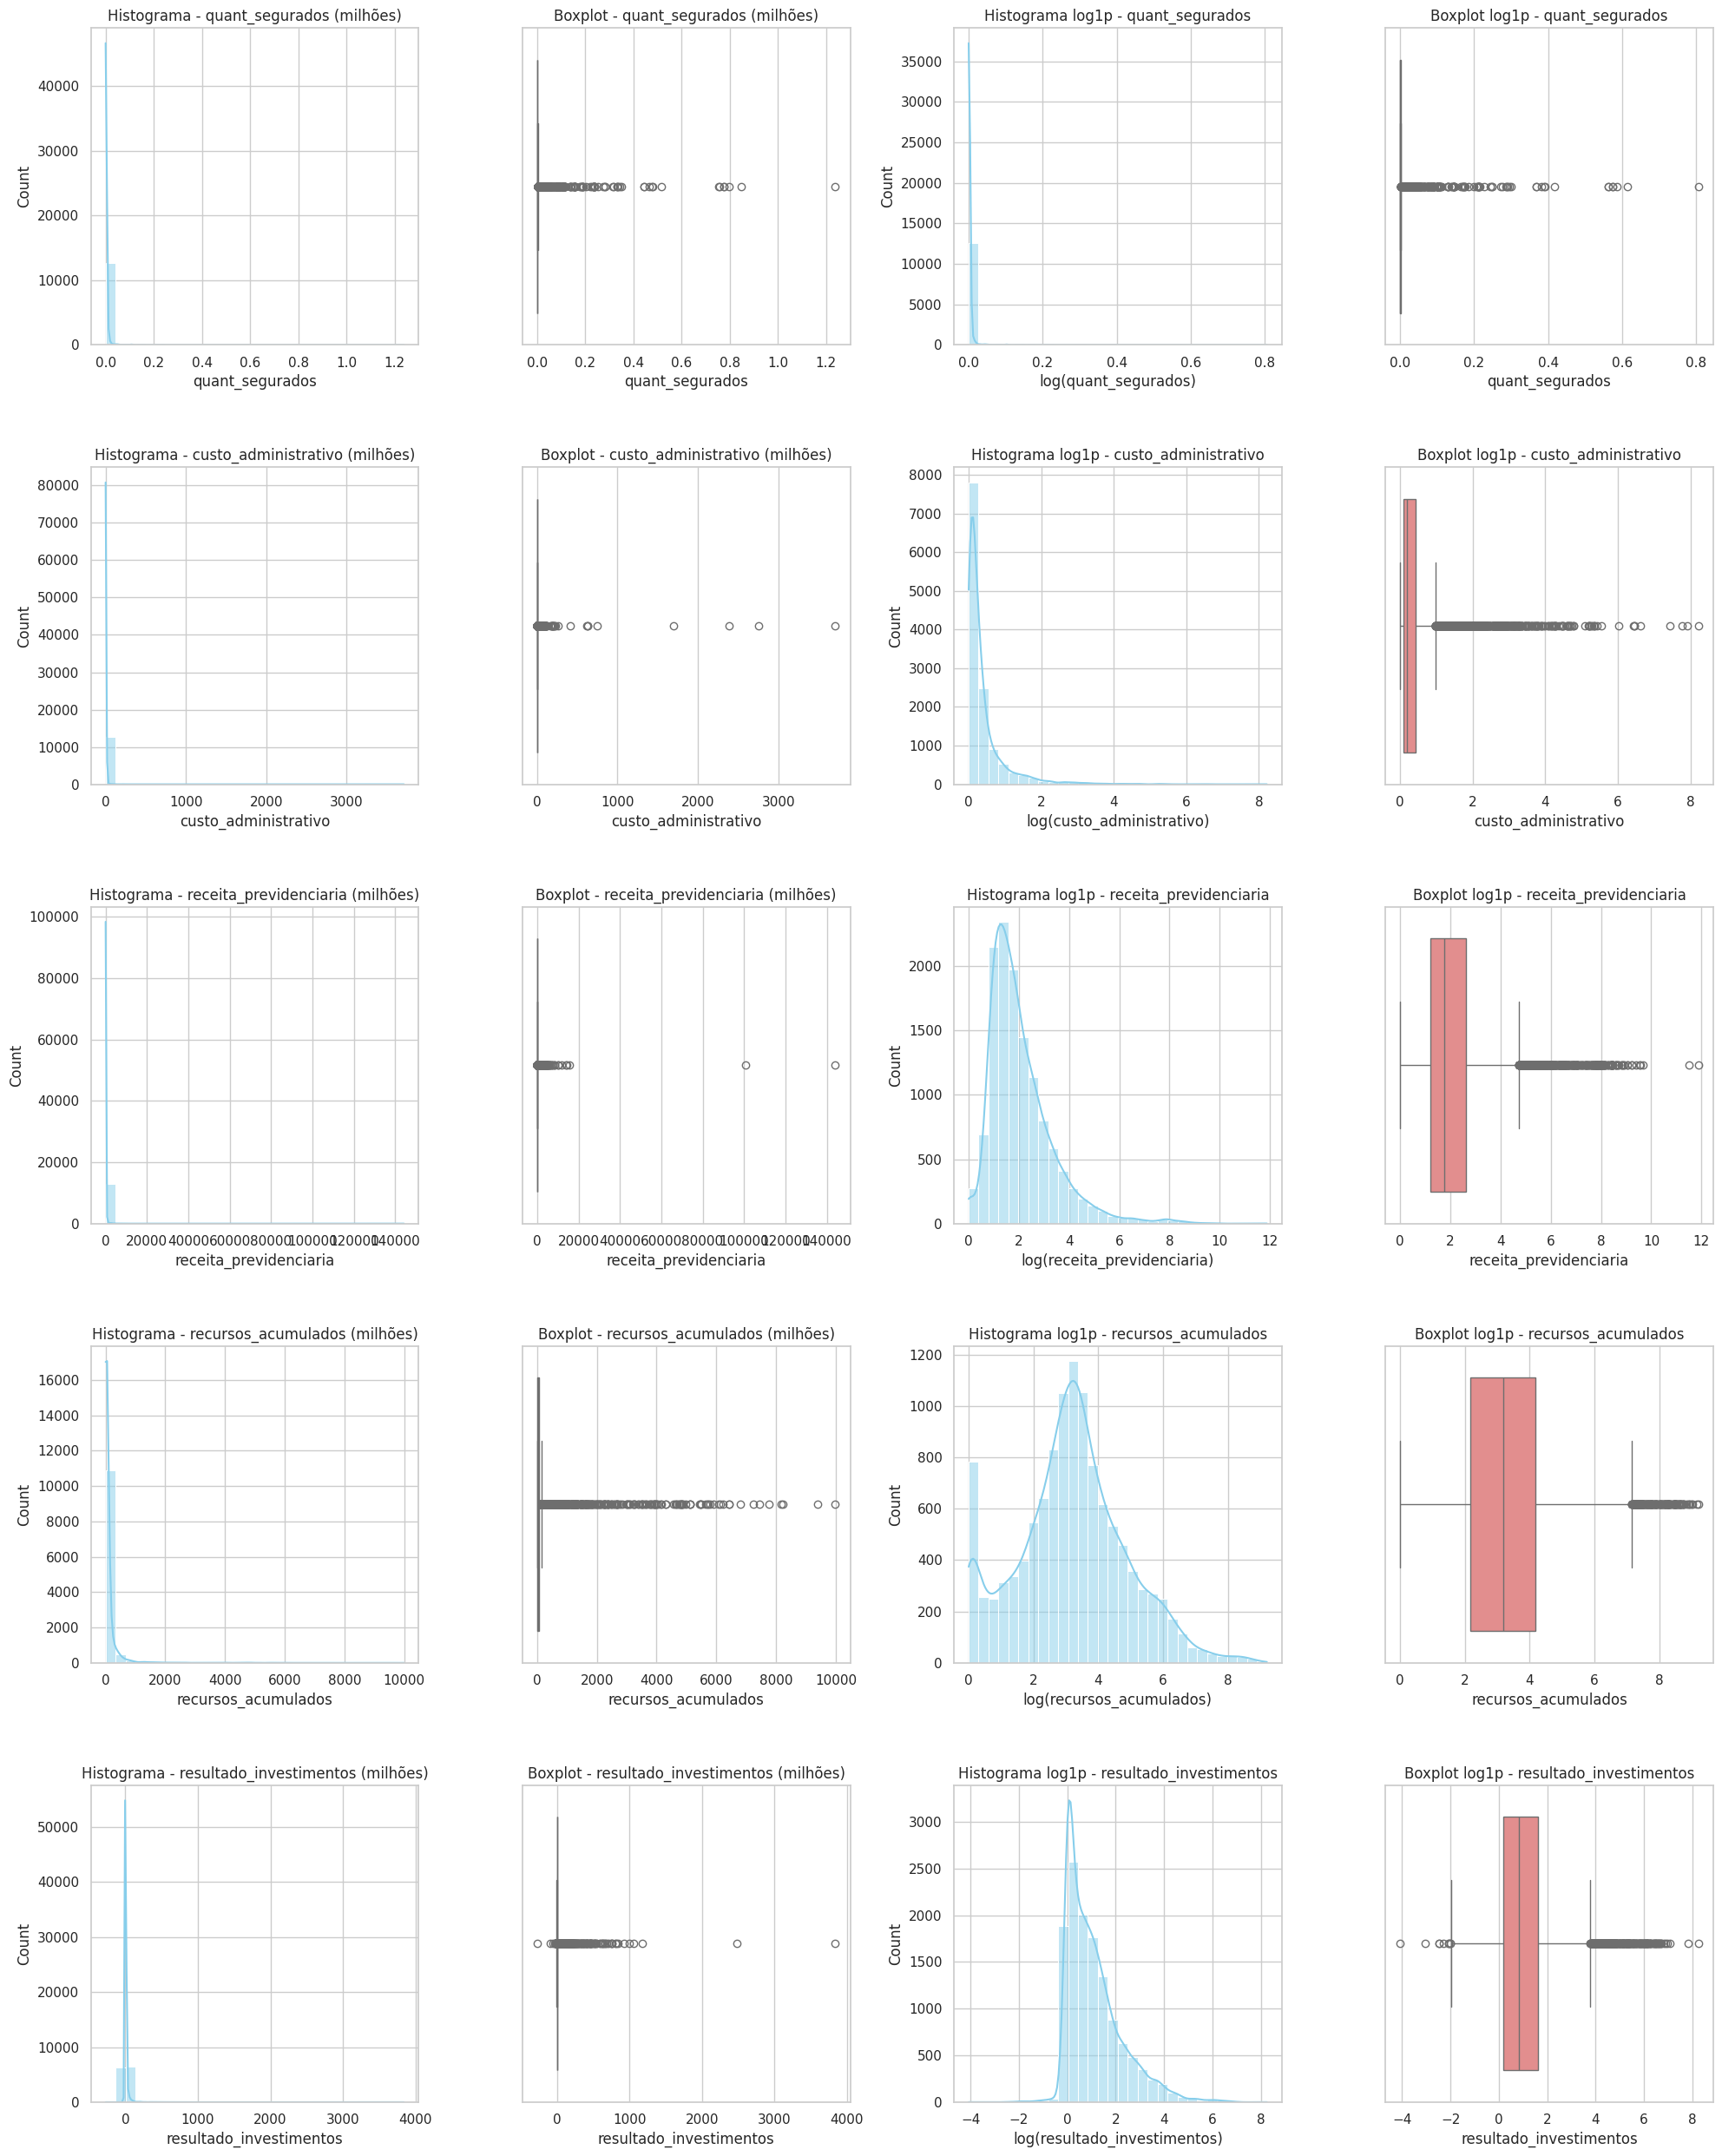

In [ ]:
# Chamada para verificar distribuição dos dados após integração
variaveis = inputs_dea + outputs_dea

plot_distribuicoes(df_modelo, variaveis)


#Marcação de outliers e valores nulos

In [ ]:
''' Marcar linhas com outliers com base no IQR, calculado separadamente por grupo de acordo com o porte e ano.
    Marca também como outliers os valores atípicos do mesmo rpps ao longo do tempo utilizando o Z Score.
    Marca as linhas com valores 0 ou NaN '''

variaveis_iqr = inputs_dea + outputs_dea

# Marcação inicial de NaN ou zeros, exceto para investimentos e aportes
for var in variaveis_iqr:
    if var not in ['resultado_investimentos', 'recursos_acumulados']:
        # Nessas variáveis, apenas NaN é problema
        cond = df_modelo[var].isna()
    else:
        # Nas demais, NaN ou zero é problema
        cond = df_modelo[var].isna() | (df_modelo[var] == 0)

    df_modelo[f'{var}_problema'] = cond

# Outliers por IQR
for var in variaveis_iqr:
    limites = df_modelo.groupby(['grupo', 'ano'])[var].agg(
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75)
    ).reset_index()
    limites['IQR'] = limites['Q3'] - limites['Q1']
    limites['lim_inf'] = limites['Q1'] - iqr_inferior * limites['IQR']
    limites['lim_sup'] = limites['Q3'] + iqr_superior * limites['IQR']

    df_modelo = df_modelo.merge(limites[['grupo', 'ano', 'lim_inf', 'lim_sup']], on=['grupo', 'ano'], how='left')
    outlier_cond = (df_modelo[var] < df_modelo['lim_inf']) | (df_modelo[var] > df_modelo['lim_sup'])
    df_modelo[f'{var}_problema'] |= outlier_cond
    df_modelo.drop(columns=['lim_inf', 'lim_sup'], inplace=True)

df_modelo.sort_values(by=['ente', 'uf', 'ano'], inplace=True)


In [ ]:
# Marcar linhas com outliers os valores atípicos do mesmo rpps ao longo do tempo utilizando o Z Score.
variaveis_zscore = inputs_dea + outputs_dea

for var in variaveis_zscore:
    df_modelo['var_pct'] = df_modelo.groupby(['ente', 'uf'])[var].pct_change(fill_method=None)

    stats = df_modelo.groupby(['ente', 'uf'])['var_pct'].agg(['mean', 'std']).reset_index()
    stats.rename(columns={'mean': 'media_var', 'std': 'desvio_var'}, inplace=True)

    for col in ['media_var', 'desvio_var']:
        if col in df_modelo.columns:
            df_modelo.drop(columns=col, inplace=True)

    df_modelo = df_modelo.merge(stats, on=['ente', 'uf'], how='left')

    cond_outlier = (
        (df_modelo['var_pct'] < df_modelo['media_var'] - z_score * df_modelo['desvio_var']) |
        (df_modelo['var_pct'] > df_modelo['media_var'] + z_score * df_modelo['desvio_var'])
    )
    df_modelo[f'{var}_problema'] |= cond_outlier

    df_modelo.drop(columns=['var_pct', 'media_var', 'desvio_var'], inplace=True)

In [ ]:
# Filtragem de colunas e resumo para verificação
colunas_problema = [col for col in df_modelo.columns if col.endswith('_problema')]
df_modelo = df_modelo[variaveis_utilizadas + colunas_problema].copy()

# Resumo final
rpps_com_problema = df_modelo[df_modelo[colunas_problema].any(axis=1)][['ente', 'uf']].drop_duplicates().shape[0]
print(f"RPPS com algum problema detectado: {rpps_com_problema}")

RPPS com algum problema detectado: 1141


#Verificação de Monotonicidade e Colinearidade

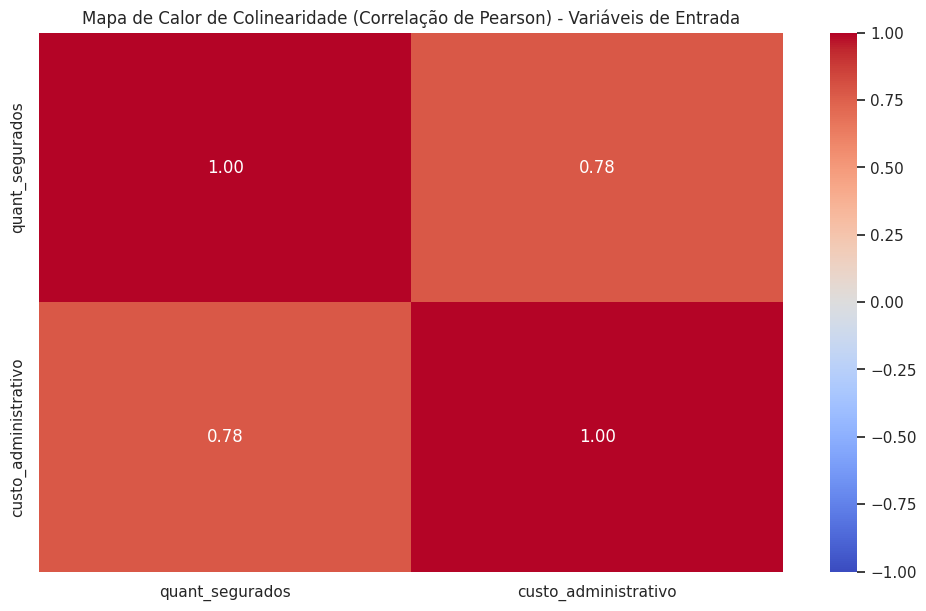


 Fatores de Inflação da Variância (VIF):
               Variável       VIF
2  custo_administrativo  2.508463
1       quant_segurados  2.508463


In [ ]:
# Análisar a colinearidade entre as variáveis que serão utilizadas como input na DEA. Desconsidera as linhas marcadas com Zero, NaN ou Outlier na etapa anterior

#Lista das variáveis de entrada
variaveis_entrada = inputs_dea

# Cria a máscara: True para linhas sem problemas nas variáveis de entrada
colunas_problema_entrada = [f'{v}_problema' for v in variaveis_entrada]
mascara_valida = ~df_modelo[colunas_problema_entrada].any(axis=1)

# Aplica a máscara e seleciona apenas as variáveis de entrada
df_colinearidade = df_modelo.loc[mascara_valida, variaveis_entrada]

# Correlação de Pearson
correlacao_entrada = df_colinearidade.corr(method='pearson')

# Plotar o heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(correlacao_entrada, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Mapa de Calor de Colinearidade (Correlação de Pearson) - Variáveis de Entrada")
plt.show()

# Cálculo do VIF
# Adiciona uma constante para o cálculo do VIF
X = df_colinearidade.copy()
X = sm.add_constant(X)  # precisa do statsmodels.api como sm

# Calcula o VIF para cada variável
vif_data = pd.DataFrame()
vif_data["Variável"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Remove a linha da constante (intercepto)
vif_data = vif_data[vif_data["Variável"] != "const"]

print("\n Fatores de Inflação da Variância (VIF):")
print(vif_data.sort_values(by="VIF", ascending=False))

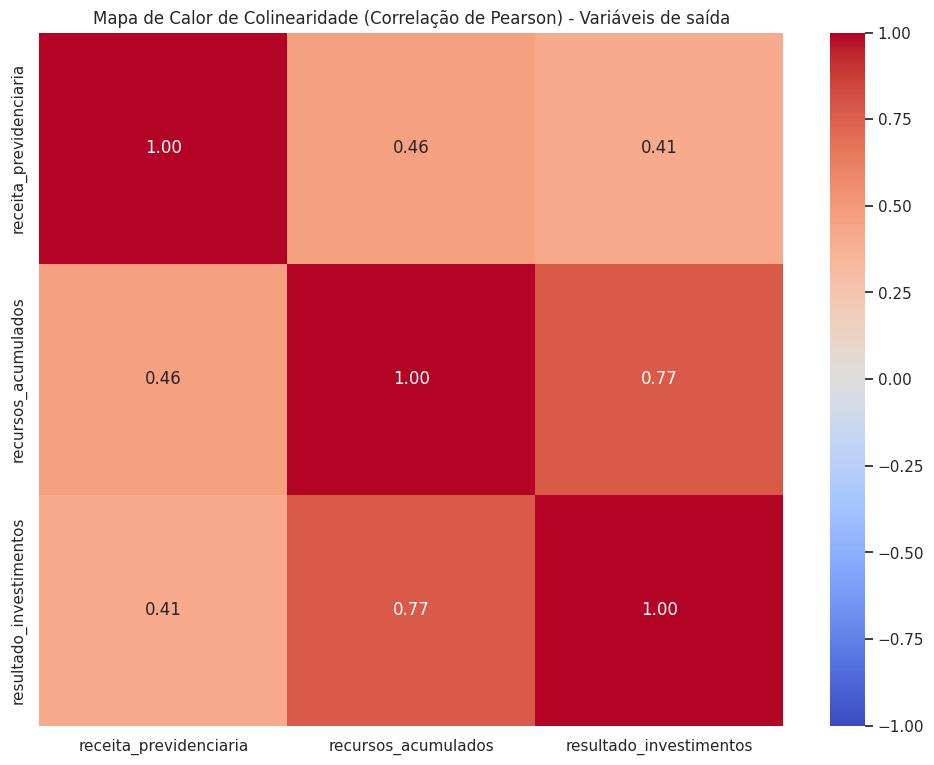


📊 Fatores de Inflação da Variância (VIF) - Variáveis de saída:
                  Variável       VIF
2      recursos_acumulados  2.654480
3  resultado_investimentos  2.508836
1   receita_previdenciaria  1.286746


In [ ]:
# Analisar a colinearidade entre as variáveis que serão utilizadas como output na DEA. Desconsidera as linhas marcadas com Zero, NaN ou Outlier na etapa anterior

# Lista das variáveis de saída
variaveis_saida = outputs_dea

# Cria a máscara: True para linhas sem problemas nas variáveis de saída
colunas_problema_saida = [f'{v}_problema' for v in variaveis_saida]
mascara_valida = ~df_modelo[colunas_problema_saida].any(axis=1)

# Aplica a máscara e seleciona apenas as variáveis de saída
df_colinearidade_saida = df_modelo.loc[mascara_valida, variaveis_saida]

# Correlação de Pearson
correlacao_saida = df_colinearidade_saida.corr(method='pearson')

# Plotar o heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(correlacao_saida, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Mapa de Calor de Colinearidade (Correlação de Pearson) - Variáveis de saída")
plt.show()


# Cálculo do VIF
# Adiciona constante para o cálculo do VIF
X_saida = sm.add_constant(df_colinearidade_saida)

# Calcula VIF para cada variável
vif_data_saida = pd.DataFrame()
vif_data_saida["Variável"] = X_saida.columns
vif_data_saida["VIF"] = [variance_inflation_factor(X_saida.values, i) for i in range(X_saida.shape[1])]

# Remove a constante
vif_data_saida = vif_data_saida[vif_data_saida["Variável"] != "const"]

print("\n📊 Fatores de Inflação da Variância (VIF) - Variáveis de saída:")
print(vif_data_saida.sort_values(by="VIF", ascending=False))


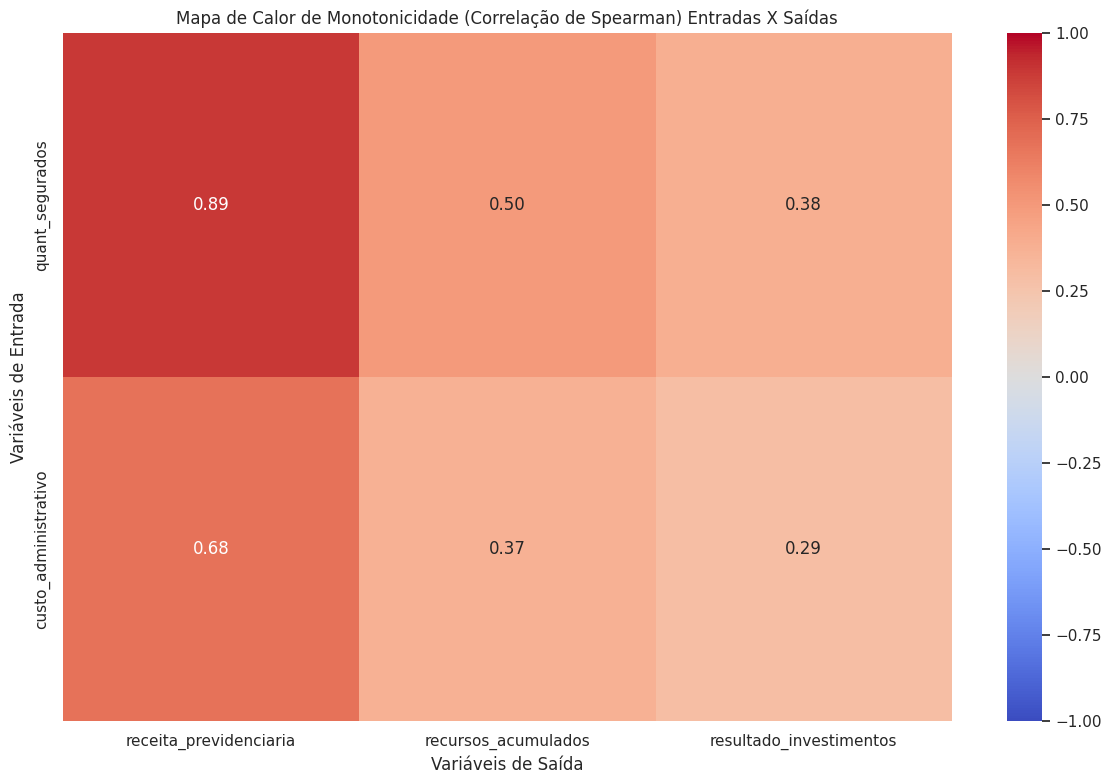

In [ ]:
# Analisar Isotonicidade das variáveis de entrada vs saída. Desconsidera as linhas marcadas com Zero, NaN ou Outlier na etapa anterior

# Definir variáveis de entrada e saída
variaveis_entrada = inputs_dea
variaveis_saida = outputs_dea

# Variáveis envolvidas na análise
variaveis_isotonicidade = variaveis_entrada + variaveis_saida

# Monta máscara para ignorar linhas com problemas em qualquer uma das variáveis
colunas_problema = [f'{v}_problema' for v in variaveis_isotonicidade if f'{v}_problema' in df_modelo.columns]
mascara_valida = ~df_modelo[colunas_problema].any(axis=1)

# Aplica a máscara e filtra os dados válidos
df_isotonicidade = df_modelo.loc[mascara_valida, variaveis_isotonicidade].dropna()

# Calcula a correlação de Spearman
correlacao_spearman = df_isotonicidade.corr(method='spearman')

# Extrai apenas correlação entre variáveis de entrada e saída
correlacao_entrada_saida = correlacao_spearman.loc[variaveis_entrada, variaveis_saida]

# Plotar o heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlacao_entrada_saida, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Mapa de Calor de Monotonicidade (Correlação de Spearman) Entradas X Saídas")
plt.xlabel("Variáveis de Saída")
plt.ylabel("Variáveis de Entrada")
plt.tight_layout()
plt.show()

#Remoção dos Outliers, valores nulos e RPPS com dados incompletos

In [ ]:
# Remover dados com outliers identificados e inserir constante para normalizar a variavel de investimentos

variaveis_entrada = inputs_dea
variaveis_saida = outputs_dea
colunas_modelo = variaveis_id + variaveis_entrada + variaveis_saida + variaveis_progestao

# Adicionar colunas de marcação relacionadas às variáveis de interesse
colunas_problema_modelo = [f'{v}_problema' for v in variaveis_entrada + variaveis_saida if f'{v}_problema' in df_modelo.columns]

# Cria o DataFrame com colunas necessárias
df_selecao = df_modelo[colunas_modelo + colunas_problema_modelo].copy()

# Criar máscara para manter apenas RPPS com dados válidos nas variáveis do modelo
mascara_valida = ~df_selecao[colunas_problema_modelo].any(axis=1)
df_selecao = df_selecao[mascara_valida].copy()

# Ajustar valores negativos em 'resultado_investimentos'
if 'resultado_investimentos' in df_selecao.columns:
    min_valor = df_selecao['resultado_investimentos'].min(skipna=True)
    if pd.notna(min_valor) and min_valor < 0:
        ajuste = abs(min_valor) + 1
        df_selecao['resultado_investimentos'] += ajuste
        print(f"Ajuste aplicado à variável 'resultado_investimentos': +{ajuste}")
    else:
        print("Nenhum ajuste necessário para 'resultado_investimentos'.")

# Função para ajustar zeros em variáveis específicas
def ajustar_zeros(df, coluna):
    if coluna in df.columns:
        # Menor valor positivo (ignorando NaN e zeros)
        min_valor = df[coluna][df[coluna] > 0].min(skipna=True)

        if pd.notna(min_valor) and (df[coluna] == 0).any():
            constante = min_valor / 2  # constante pequena
            df[coluna] = df[coluna].replace(0, constante)
            print(f"Zeros em '{coluna}' substituídos por {constante}")
        else:
            print(f"Nenhum ajuste necessário para '{coluna}'.")

# Ajustar zeros nas variáveis
ajustar_zeros(df_selecao, 'recursos_acumulados')


Ajuste aplicado à variável 'resultado_investimentos': +29862452.79
Nenhum ajuste necessário para 'recursos_acumulados'.


In [ ]:
# Retira da base os RPPS que não possuem dados completos nos 6 anos analisados.

# Contagem de anos por RPPS
frequencia = df_selecao.groupby(['ente', 'uf']).agg(qtd_anos=('ano', 'nunique')).reset_index()
rpps_completos = frequencia[frequencia['qtd_anos'] == 6][['ente', 'uf']]

# Filtra apenas RPPS com 6 anos completos
df_limpo = df_selecao.merge(rpps_completos, on=['ente', 'uf'], how='inner')

# Resultado
total_rpps = df_limpo[['ente', 'uf']].drop_duplicates().shape[0]
rpps_certificados = df_limpo[df_limpo['data_cert_inicial'].notna()][['ente', 'uf']].drop_duplicates().shape[0]
rpps_nao_certificados = total_rpps - rpps_certificados

print(f"RPPS com 6 anos completos e sem problemas: {total_rpps}")
print(f"→ RPPS certificados: {rpps_certificados}")
print(f"→ RPPS não certificados: {rpps_nao_certificados}")
print(f"Linhas finais no df_limpo: {df_limpo.shape[0]}")

RPPS com 6 anos completos e sem problemas: 1016
→ RPPS certificados: 107
→ RPPS não certificados: 909
Linhas finais no df_limpo: 6096


#2ª Verificação da distribuição dos dados

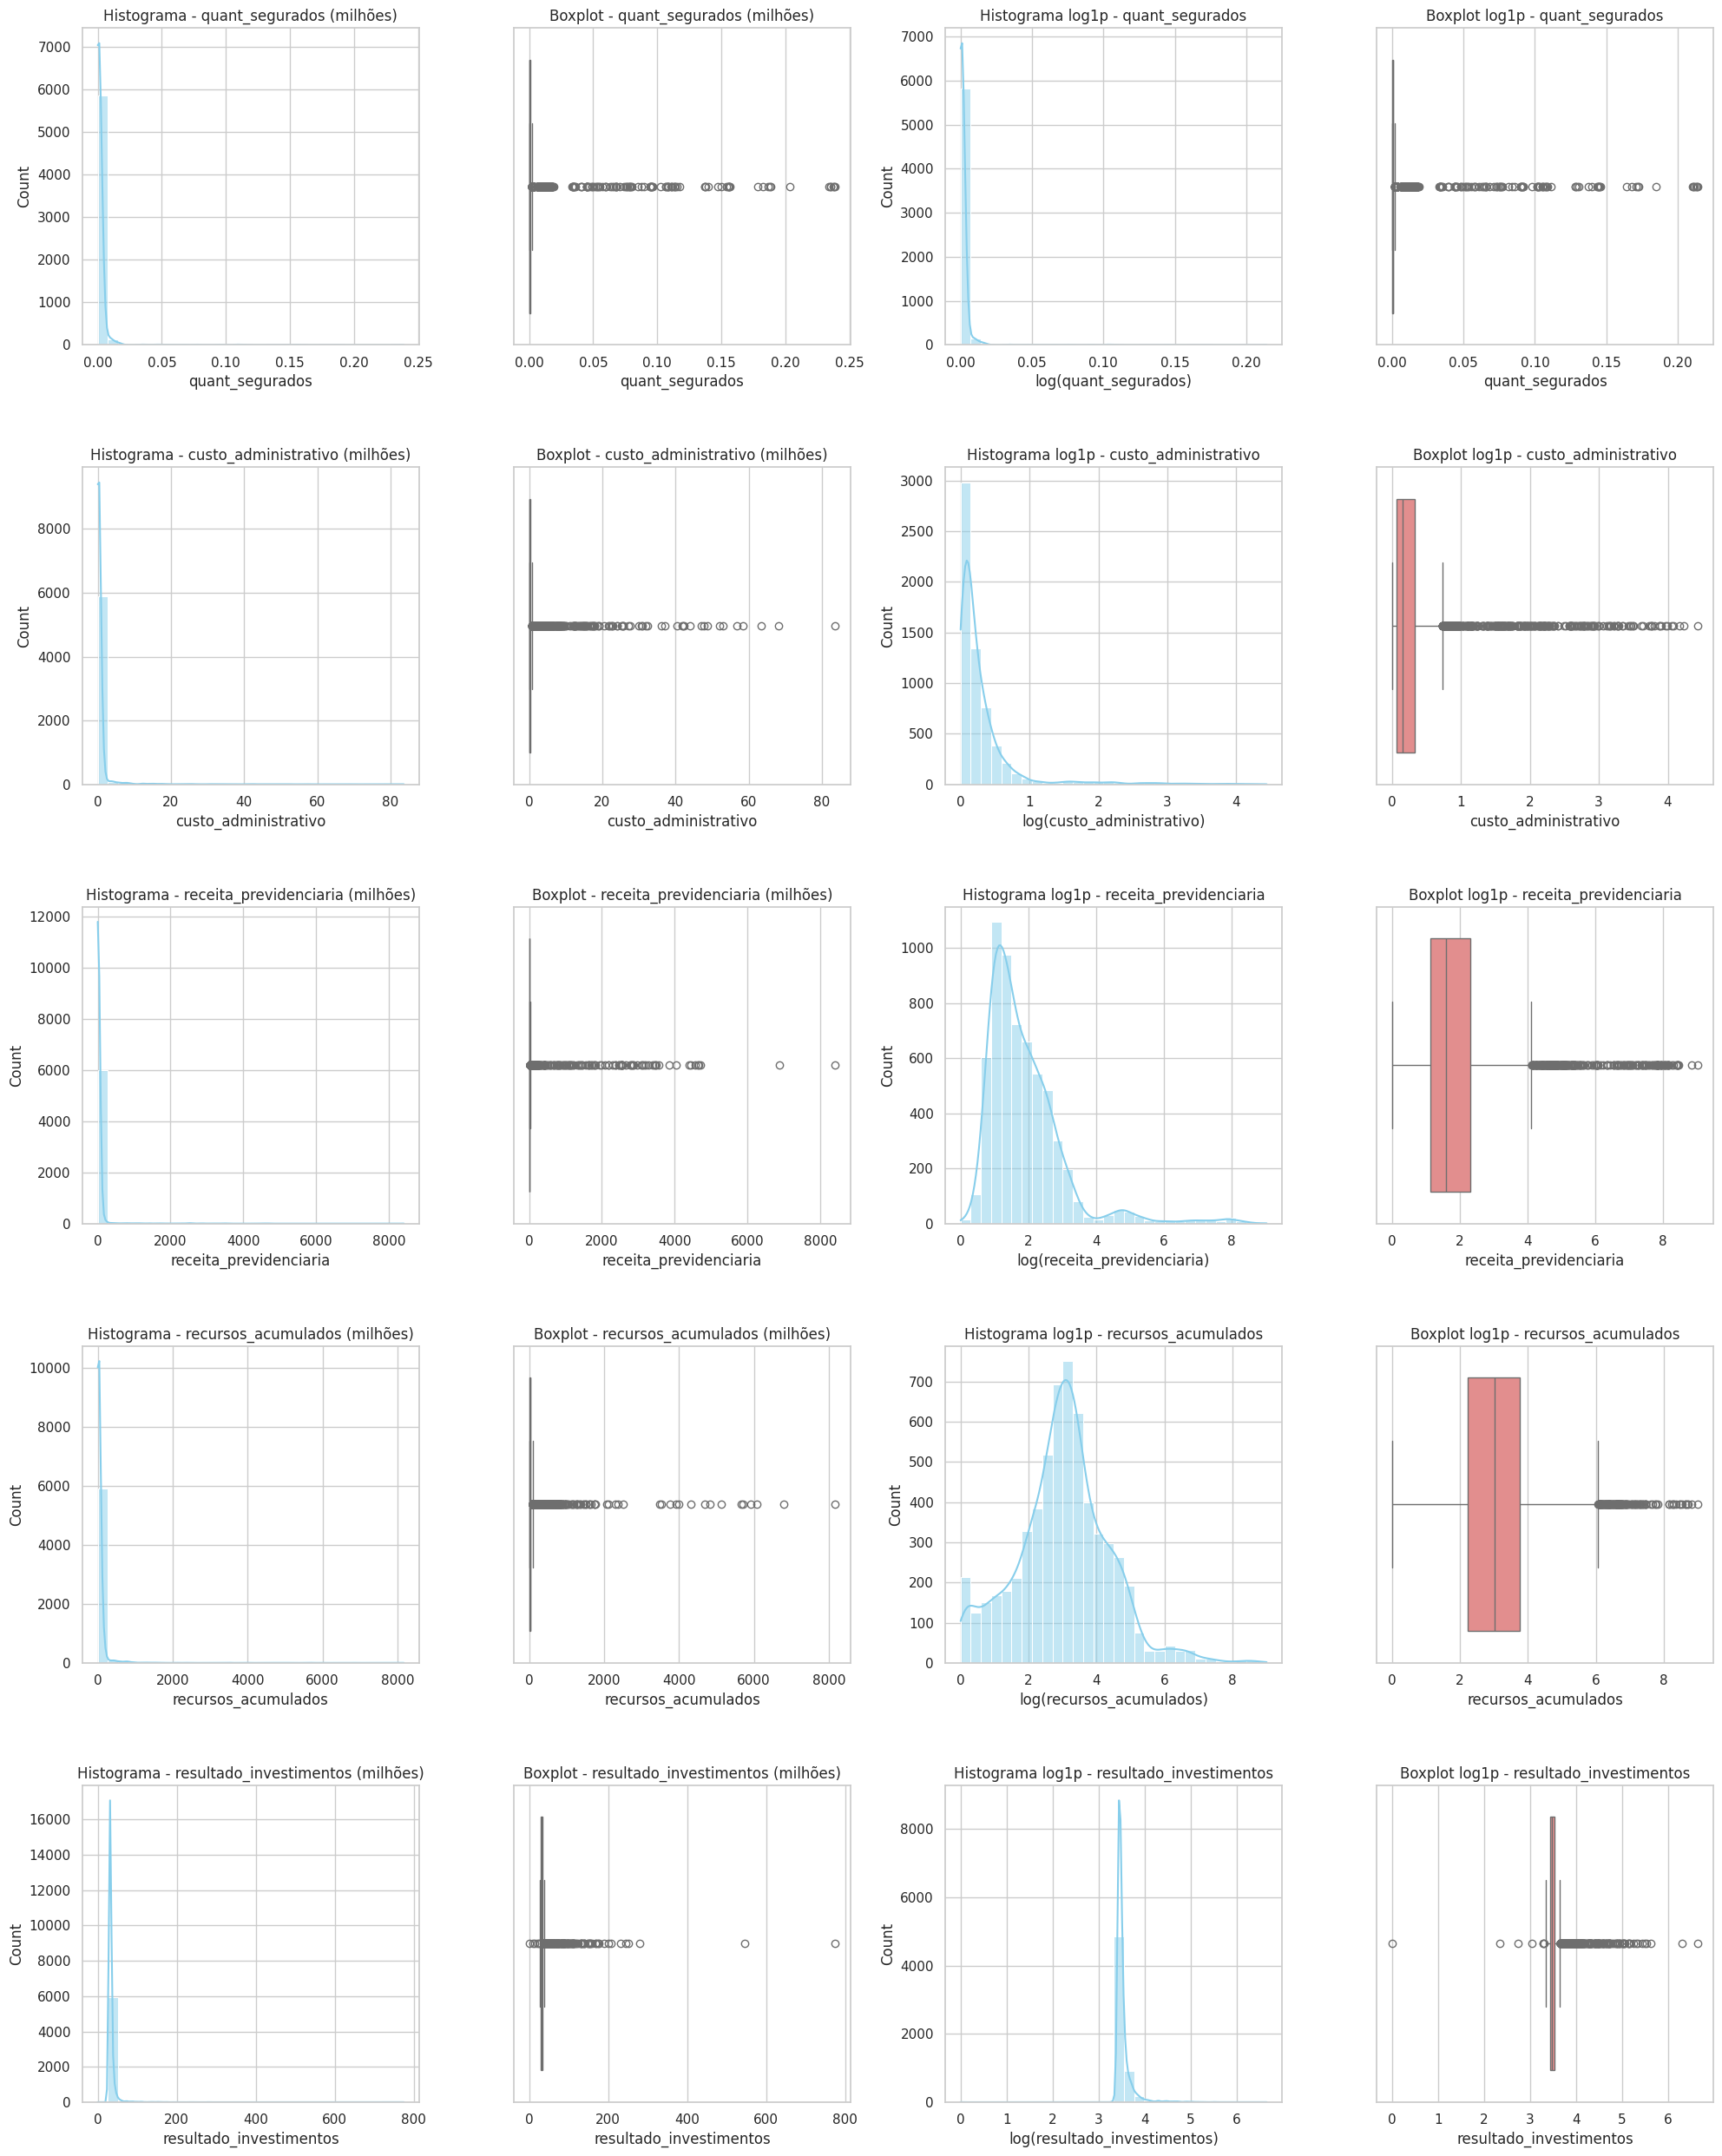

In [ ]:
# Chamada para verificar distribuição dos dados após limpeza
variaveis = inputs_dea + outputs_dea

plot_distribuicoes(df_limpo, variaveis)

In [ ]:
# Visualizar estrutura após limpeza
print("Estrutura do dataset limpo:")
print(df_limpo.info())

# Salvar em Excel e csv
#df_limpo.to_excel('dataset_limpo.xlsx', index=False)
#df_limpo.to_csv('dataset_limpo_completo.csv', index=False)

# baixar arquivo
#files.download('dataset_limpo.xlsx')
#files.download('dataset_limpo_completo.csv')

Estrutura do dataset limpo:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6096 entries, 0 to 6095
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ente                              6096 non-null   object 
 1   uf                                6096 non-null   object 
 2   ano                               6096 non-null   int64  
 3   cnpj                              263 non-null    object 
 4   quant_segurados                   6096 non-null   int64  
 5   custo_administrativo              6096 non-null   float64
 6   receita_previdenciaria            6096 non-null   float64
 7   recursos_acumulados               6096 non-null   float64
 8   resultado_investimentos           6096 non-null   float64
 9   grupo                             6096 non-null   object 
 10  data_cert_inicial                 107 non-null    object 
 11  nivel_inicial                     107 non

#Seleção de DMUs do grupo de controle com Aplicação do PSM

In [ ]:
# Remove os RPPS que obtiveram certificação fora do período analisado

# Extrai apenas as linhas de 2023, onde está a informação de certificação
df_cert_2023 = df_limpo[df_limpo['ano'] == 2023].copy()
df_cert_2023['ano_certificacao'] = pd.to_datetime(df_cert_2023['data_cert_inicial'], errors='coerce').dt.year

# Identifica os entes que se certificaram fora do intervalo analisado
entes_excluir = df_cert_2023[
    (df_cert_2023['ano_certificacao'] < DataCertInicial) | (df_cert_2023['ano_certificacao'] > DataCertFinal)
][['ente', 'uf']]

# Remove todas as linhas desses entes do DataFrame limpo
df_limpo = df_limpo.merge(entes_excluir, on=['ente', 'uf'], how='left', indicator=True)
df_limpo = df_limpo[df_limpo['_merge'] == 'left_only'].drop(columns=['_merge'])

# informações do df_limpo
print("Estrutura do dataset limpo:")
print(df_limpo.info())

# Cria uma tabela resumo do DataFrame
resumo = pd.DataFrame({
    'coluna': df_limpo.columns,
    'tipo_dado': df_limpo.dtypes.values,
    'nao_nulos': df_limpo.notna().sum().values,
    'nulos': df_limpo.isna().sum().values,
    'percentual_nulos': (df_limpo.isna().sum() / len(df_limpo) * 100).round(2).values,
    'valores_unicos': df_limpo.nunique().values
})

# Gera tabela resumo formatada
resumo_formatado = resumo.copy()
resumo_formatado['tipo_dado'] = resumo_formatado['tipo_dado'].astype(str)
resumo_formatado['percentual_nulos'] = resumo_formatado['percentual_nulos'].map(lambda x: f"{x:.2f}%")

# Ajusta para exibição limpa
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.colheader_justify', 'center')

# Reorganiza a ordem das colunas
resumo = resumo[['coluna', 'tipo_dado', 'nao_nulos', 'nulos', 'percentual_nulos', 'valores_unicos']]

# Baixar os arquivos
#df_limpo.to_excel('dataset_limpo.xlsx', index=False)
#files.download('dataset_limpo.xlsx')

#resumo.to_excel('resumo_limpo.xlsx', index=False)
#files.download('resumo_limpo.xlsx')


Estrutura do dataset limpo:
<class 'pandas.core.frame.DataFrame'>
Index: 5958 entries, 0 to 6095
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ente                              5958 non-null   object 
 1   uf                                5958 non-null   object 
 2   ano                               5958 non-null   int64  
 3   cnpj                              240 non-null    object 
 4   quant_segurados                   5958 non-null   int64  
 5   custo_administrativo              5958 non-null   float64
 6   receita_previdenciaria            5958 non-null   float64
 7   recursos_acumulados               5958 non-null   float64
 8   resultado_investimentos           5958 non-null   float64
 9   grupo                             5958 non-null   object 
 10  data_cert_inicial                 84 non-null     object 
 11  nivel_inicial                     84 non-null 

In [ ]:
def parear_rpps(df_limpo, caliper=calibre_psm):
    """
    Aplica Propensity Score Matching por grupo de RPPS, garantindo que
    apenas entidades não certificadas sejam usadas como controles.
    Retorna um dict com:
      - 'pares': DataFrame de pares tratado/controle com valores originais
      - 'ano_<YYYY>': DataFrame completo dos RPPS emparelhados em cada ano
    """
    variaveis_preditoras = variaveis_psm
    resultados = {}

    # Base de 2018 e datas de certificação de 2023
    df_2018 = df_limpo[df_limpo['ano'] == 2018].copy()
    df_cert_2023 = df_limpo[df_limpo['ano'] == 2023][['ente', 'uf', 'data_cert_inicial']]
    df_2018 = pd.merge(df_2018.drop(columns=['data_cert_inicial'], errors='ignore'),
                       df_cert_2023, on=['ente', 'uf'], how='left')
    df_2018['ano_certificacao'] = (
        pd.to_datetime(df_2018['data_cert_inicial'], errors='coerce')
          .dt.year
    )

    # NOVO: variável para treino do modelo (qualquer certificado em qualquer ano)
    df_2018['tratamento_modelo'] = np.where(
        df_2018['ano_certificacao'].notna(), 1, 0
    )

    # NOVO: variável para pareamento (somente certificados no intervalo desejado)
    df_2018['tratamento_pareamento'] = np.where(
        df_2018['ano_certificacao'].between(DataCertInicial, DataCertFinal), 1, 0
    )

    # Guarda valores originais antes de qualquer transformação
    df_originais = df_2018[['ente', 'uf'] + variaveis_preditoras].copy()
    todos_os_pares = []

    for grupo_nome, df_grupo in df_2018.groupby('grupo'):
        df_grupo = df_grupo.copy()

        # Log-transform nas variáveis preditoras
        for col in variaveis_preditoras:
            df_grupo[col] = np.log1p(df_grupo[col])

        X = df_grupo[variaveis_preditoras]
        y = df_grupo['tratamento_modelo']  # Treino com todos certificados
        if y.nunique() < 2:
            print(f"Grupo '{grupo_nome}' sem variedade de tratamento; pulando.")
            continue

        # Escalonamento e ajuste do modelo
        scaler = StandardScaler()
        X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
        modelo = LogisticRegression(max_iter=1000)
        modelo.fit(X_scaled, y)
        df_grupo['score'] = modelo.predict_proba(X_scaled)[:, 1]

        # Separar tratados para pareamento (somente certificados no intervalo)
        tratados = df_grupo[df_grupo['tratamento_pareamento'] == 1].reset_index(drop=True)

        # Separar controles (somente nunca certificados)
        controles = df_grupo[
            (df_grupo['tratamento_modelo'] == 0) &
            (df_grupo['ano_certificacao'].isna())
        ].reset_index(drop=True)

        pares = []
        usados = set()
        for i, tr in tratados.iterrows():
            score_t = tr['score']
            dist = (controles['score'] - score_t).abs()
            candidatos = dist[dist <= caliper].sort_values()
            for idx in candidatos.index:
                if idx not in usados:
                    pares.append((i, idx))
                    usados.add(idx)
                    break

        if not pares:
            print(f"Nenhum par encontrado no grupo '{grupo_nome}'.")
            continue

        # Montar DataFrame de pares com valores originais
        tratados_p = tratados.loc[[i for i, _ in pares]].copy()
        controles_p = controles.loc[[j for _, j in pares]].copy()

        tratados_orig = pd.merge(
            tratados_p[['ente', 'uf', 'score']],
            df_originais, on=['ente', 'uf'], how='left'
        )
        controles_orig = pd.merge(
            controles_p[['ente', 'uf', 'score']],
            df_originais, on=['ente', 'uf'], how='left'
        )

        df_pares = pd.concat([
            tratados_orig.add_prefix('tratado_').reset_index(drop=True),
            controles_orig.add_prefix('controle_').reset_index(drop=True)
        ], axis=1)
        todos_os_pares.append(df_pares)

    # Resultado final: pares e séries anuais
    if todos_os_pares:
        df_pares_final = pd.concat(todos_os_pares, ignore_index=True)
        resultados['pares'] = df_pares_final

        # Identificar entes emparelhados
        entes = pd.concat([
            df_pares_final[['tratado_ente','tratado_uf']]
               .rename(columns={'tratado_ente':'ente','tratado_uf':'uf'}),
            df_pares_final[['controle_ente','controle_uf']]
               .rename(columns={'controle_ente':'ente','controle_uf':'uf'})
        ]).drop_duplicates()
        emp = df_limpo[
            df_limpo[['ente','uf']].apply(tuple,1)
            .isin(entes.apply(tuple,1))
        ]
        emp = emp[emp['ano'].between(DataCertInicial, DataCertFinal)]
        for ano in sorted(emp['ano'].unique()):
            resultados[f'ano_{ano}'] = emp[emp['ano'] == ano].copy()
    else:
        print("Nenhum par encontrado em nenhum grupo.")

    return resultados



In [ ]:
# Chamada para a função de aplicação do PSM
dfs_pareados_geral = parear_rpps(df_limpo)

In [ ]:
# Gerar Excel com os pares formados no PSM geral e baixar os arquivos
#dfs_pareados_geral['pares'].to_excel('pares_psm_geral.xlsx', index=False)
#files.download('pares_psm_geral.xlsx')

# Informações do df_pareados geral
print("Estrutura do df_pareados geral:")
print(dfs_pareados_geral['pares'].info())


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Estrutura do df_pareados geral:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 16 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   tratado_ente                      58 non-null     object 
 1   tratado_uf                        58 non-null     object 
 2   tratado_score                     58 non-null     float64
 3   tratado_quant_segurados           58 non-null     int64  
 4   tratado_custo_administrativo      58 non-null     float64
 5   tratado_receita_previdenciaria    58 non-null     float64
 6   tratado_recursos_acumulados       58 non-null     float64
 7   tratado_resultado_investimentos   58 non-null     float64
 8   controle_ente                     58 non-null     object 
 9   controle_uf                       58 non-null     object 
 10  controle_score                    58 non-null     float64
 11  controle_quant_segurados          58 non-

In [ ]:
# Separar os dados pareados em tratados e controles
df_pares = dfs_pareados_geral['pares']

# Preparar os grupos
tratados = df_pares.filter(like='tratado_').copy()
tratados.columns = [col.replace('tratado_', '') for col in tratados.columns]
tratados['grupo'] = 'Certificado'

controles = df_pares.filter(like='controle_').copy()
controles.columns = [col.replace('controle_', '') for col in controles.columns]
controles['grupo'] = 'Não certificado'

# Unir os dados
df_comparativo = pd.concat([tratados, controles], ignore_index=True)

# Variáveis para análise
variaveis = ['score'] + variaveis_psm

# Calcular estatísticas por grupo e variável
linhas = []
for var in variaveis:
    for grupo in ['Certificado', 'Não certificado']:
        df_temp = df_comparativo[df_comparativo['grupo'] == grupo]
        linha = {
            'Variável': var,
            'Grupo': grupo,
            'Média': round(df_temp[var].mean(), 2),
            'Desvio Padrão': round(df_temp[var].std(), 2),
            'Mínimo': round(df_temp[var].min(), 2),
            'Máximo': round(df_temp[var].max(), 2)
        }
        linhas.append(linha)

# Criar DataFrame da tabela
tabela_formatada = pd.DataFrame(linhas)

# Exportar para Excel
tabela_formatada.to_excel('tabela_pares_formatada.xlsx', index=False)
files.download('tabela_pares_formatada.xlsx')

# Exibir estrutura
tabela_formatada


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Variável,Grupo,Média,Desvio Padrão,Mínimo,Máximo
0,score,Certificado,0.22,1.800000e-01,0.01,7.600000e-01
1,score,Não certificado,0.22,1.800000e-01,0.01,7.500000e-01
2,quant_segurados,Certificado,3638.78,1.506615e+04,169.00,1.151230e+05
3,quant_segurados,Não certificado,3535.57,1.344666e+04,114.00,1.026990e+05
4,custo_administrativo,Certificado,1377328.40,5.323797e+06,42716.47,4.037868e+07
5,custo_administrativo,Não certificado,873688.52,2.341561e+06,46.75,1.780780e+07
6,receita_previdenciaria,Certificado,51194417.57,2.739521e+08,996690.28,2.091397e+09
7,receita_previdenciaria,Não certificado,35479451.79,1.583051e+08,1082830.53,1.205555e+09
8,recursos_acumulados,Certificado,62529483.50,5.581471e+07,1417809.00,3.033832e+08
9,recursos_acumulados,Não certificado,62893239.52,5.230473e+07,6061808.99,3.069825e+08


#Cálculo da DEA utilizando o R

In [ ]:
# função para gerar os arquivos para análise dea no r
def exportar_dfs_dea(dfs_pareados, inputs, outputs):
    dfs_gerados = {}

    if not inputs or not outputs:
        print('É necessário ao menos uma variável de entrada e uma de saída.')
        return dfs_gerados

    for nome, df_selecionado in dfs_pareados.items():
        # ignora o DataFrame de pares
        if nome == 'pares':
            continue

        df_selecionado = df_selecionado.copy()

        # tratamento para estrutura de pares (com prefixos tratado_ / controle_)
        if any(col.startswith('tratado_') for col in df_selecionado.columns):
            tratados = df_selecionado.filter(like='tratado_').copy()
            tratados.columns = [col.replace('tratado_', '') for col in tratados.columns]
            tratados['grupo'] = 'Certificado'

            controles = df_selecionado.filter(like='controle_').copy()
            controles.columns = [col.replace('controle_', '') for col in controles.columns]
            controles['grupo'] = 'Não certificado'

            df_selecionado = pd.concat([tratados, controles], ignore_index=True)

        colunas_necessarias = {'ente', 'uf', 'ano'} | set(inputs) | set(outputs)
        if not colunas_necessarias.issubset(df_selecionado.columns):
            print(f'Colunas faltando em {nome}, ignorado.')
            continue

        df_selecionado['ente_uf'] = df_selecionado['ente'].astype(str).str.strip() + '_' + df_selecionado['uf'].astype(str).str.strip()

        colunas_export = ['ente_uf'] + inputs + outputs + ['ano']
        df_export = df_selecionado[colunas_export].copy()

        colunas_renomeadas = (
            ['RPPS'] +
            [f'Input{i+1}' for i in range(len(inputs))] +
            [f'Output{i+1}' for i in range(len(outputs))] +
            ['Ano']
        )
        df_export.columns = colunas_renomeadas

        if df_export.iloc[:, 1:-1].isnull().any().any():
            print(f'Dados faltantes em {nome}, ignorado.')
            continue

        dfs_gerados[nome] = df_export
        print(f'DF gerado: {nome}')

    return dfs_gerados


In [ ]:
# Chamada para pareamento modo Geral
dfs_gerados = exportar_dfs_dea(dfs_pareados_geral, inputs_dea, outputs_dea)

DF gerado: ano_2018
DF gerado: ano_2019
DF gerado: ano_2020
DF gerado: ano_2021
DF gerado: ano_2022
DF gerado: ano_2023


In [ ]:
# transfere os dataframes para o R
from rpy2.robjects import pandas2ri
import rpy2.robjects as ro

pandas2ri.activate()

for nome, df in dfs_gerados.items():
    ro.globalenv[f'df_{nome}'] = pandas2ri.py2rpy(df)

print("Dataframes transferidos para o ambiente R.")

Dataframes transferidos para o ambiente R.


In [ ]:
# Ativa o R no colab
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
%%R

# Instalação dos pacotes
install.packages("Benchmarking")
install.packages("dplyr")

library(Benchmarking)
library(dplyr)

# gerar nomes dinamicamente
input_vars <- paste0("Input", 1:n_inputs)
output_vars <- paste0("Output", 1:n_outputs)

resultados_totais <- list()

for (nome in ls(pattern = "^df_")) {
  cat("Processando:", nome, "\n")

  dados <- get(nome)

  inputs <- as.matrix(dados[, input_vars])
  outputs <- as.matrix(dados[, output_vars])

  resultado <- dea(X = inputs, Y = outputs, RTS = "vrs", ORIENTATION = "out")
  eficiencia <- 1 / resultado$eff

  dados_resultado <- data.frame(
    RPPS = dados$RPPS,
    Ano = dados$Ano,
    Grupo = gsub("df_", "", nome),
    Eficiencia = eficiencia
  )

  resultados_totais[[nome]] <- dados_resultado
}

# consolidar os resultados
resultados_dea <- bind_rows(resultados_totais)

# exibir exemplo do resultado
print(head(resultados_dea))

Processando: df_ano_2018 
Processando: df_ano_2019 
Processando: df_ano_2020 
Processando: df_ano_2021 
Processando: df_ano_2022 
Processando: df_ano_2023 
                     RPPS  Ano    Grupo Eficiencia
12            ACOPIARA_CE 2018 ano_2018  0.8126846
246           ANAPOLIS_GO 2018 ano_2018  0.7858840
252             ANDIRA_PR 2018 ano_2018  0.8479299
336         AQUIDAUANA_MS 2018 ano_2018  0.8604790
366            ARAPOTI_PR 2018 ano_2018  0.9378630
408 ARMACAO DOS BUZIOS_RJ 2018 ano_2018  0.8292852


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘lpSolveAPI’, ‘ucminf’, ‘quadprog’

trying URL 'https://cran.rstudio.com/src/contrib/lpSolveAPI_5.5.2.0-17.14.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/ucminf_1.2.2.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/quadprog_1.5-8.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/Benchmarking_0.33.tar.gz'

The downloaded source packages are in
	‘/tmp/Rtmp53kYCp/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/dplyr_1.1.4.tar.gz'
Content type 'application/x-gzip' length 1207521 bytes (1.2 MB)
downloaded 1.2 MB


The downloaded source packages are in
	‘/tmp/Rtmp53kYCp/downloaded_packages’
Loading required package: lpSolveAPI
Loading required package: ucminf
Loading required package: quadprog

Attaching package: ‘dplyr’

The following objects are 

#Análise dos Resultados

In [ ]:
# Transfere o dataframe de resultados_dea do R para o Python novamente

from rpy2.robjects import pandas2ri
import rpy2.robjects as ro

pandas2ri.activate()

# Recupera o dataframe R para o Python
resultados_dea_py = pandas2ri.rpy2py(ro.globalenv['resultados_dea'])

# Exibe as primeiras linhas para conferência
print(resultados_dea_py.head(20))


                RPPS              Ano   Grupo    Eficiencia
12                  ACOPIARA_CE  2018  ano_2018   0.812685 
246                 ANAPOLIS_GO  2018  ano_2018   0.785884 
252                   ANDIRA_PR  2018  ano_2018   0.847930 
336               AQUIDAUANA_MS  2018  ano_2018   0.860479 
366                  ARAPOTI_PR  2018  ano_2018   0.937863 
408       ARMACAO DOS BUZIOS_RJ  2018  ano_2018   0.829285 
492   BALNEARIO BARRA DO SUL_SC  2018  ano_2018   0.998226 
546              BARRA VELHA_SC  2018  ano_2018   0.834289 
576                 BEBERIBE_CE  2018  ano_2018   0.818381 
648         BOA VISTA DO SUL_RS  2018  ano_2018   1.000000 
654                 BOCAIUVA_MG  2018  ano_2018   0.781433 
774                  BRUSQUE_SC  2018  ano_2018   0.888536 
840                  CACADOR_SC  2018  ano_2018   0.915161 
852              CACAULANDIA_RO  2018  ano_2018   0.964535 
906                 CAIEIRAS_SP  2018  ano_2018   0.881012 
936                 CAMACARI_BA  2018  a

In [ ]:
# Adiciona colunas no resultado com os dados dos RPPS do df_limpo

# Copia o resultado do DEA
resultado = resultados_dea_py.copy()

# Padronização dos nomes para merge correto
resultado['RPPS'] = resultado['RPPS'].str.upper().str.strip()
df_limpo['ente'] = df_limpo['ente'].str.upper().str.strip()
df_limpo['uf'] = df_limpo['uf'].str.upper().str.strip()

# Cria chave ente_uf
df_limpo['ente_uf'] = df_limpo['ente'] + "_" + df_limpo['uf']

# Extrai as informações de certificação de 2023
cert_info = (
    df_limpo[df_limpo['ano'] == 2023]
    [['ente_uf', 'data_cert_inicial', 'nivel_inicial', 'grupo']]
    .copy()
)

cert_info['data_cert_inicial'] = pd.to_datetime(cert_info['data_cert_inicial'], errors='coerce')
cert_info['certificado'] = cert_info['data_cert_inicial'].notna()
cert_info['ano_cert_inicial'] = cert_info['data_cert_inicial'].dt.year
cert_info['grupo_certificacao'] = cert_info['certificado'].apply(
    lambda x: 'Certificado' if x else 'Não Certificado'
)

# Faz o merge com o resultado DEA
df_merged = resultado.merge(
    cert_info,
    left_on='RPPS',
    right_on='ente_uf',
    how='left'
)

# Mantém apenas colunas relevantes
df_merged = df_merged[[
    'RPPS', 'grupo', 'Ano', 'Eficiencia', 'nivel_inicial', 'ano_cert_inicial', 'grupo_certificacao'
]]

# Visualização inicial
print(df_merged.head(20))

# baixar em excel
#df_merged.to_excel('df_merged.xlsx', index=False)
#files.download('df_merged.xlsx')


              RPPS                grupo        Ano  Eficiencia nivel_inicial  ano_cert_inicial grupo_certificacao
0                 ACOPIARA_CE    MÉDIO PORTE  2018   0.812685        NaN              NaN        Não Certificado 
1                 ANAPOLIS_GO   GRANDE PORTE  2018   0.785884        NaN              NaN        Não Certificado 
2                   ANDIRA_PR    MÉDIO PORTE  2018   0.847930          I           2023.0            Certificado 
3               AQUIDAUANA_MS    MÉDIO PORTE  2018   0.860479          I           2021.0            Certificado 
4                  ARAPOTI_PR    MÉDIO PORTE  2018   0.937863        NaN              NaN        Não Certificado 
5       ARMACAO DOS BUZIOS_RJ    MÉDIO PORTE  2018   0.829285          I           2023.0            Certificado 
6   BALNEARIO BARRA DO SUL_SC  PEQUENO PORTE  2018   0.998226          I           2020.0            Certificado 
7              BARRA VELHA_SC    MÉDIO PORTE  2018   0.834289          I           2021.

In [ ]:
# Faz o pivot incluindo ano_cert_inicial
pivot = df_merged.pivot_table(
    index=['RPPS', 'grupo', 'grupo_certificacao'],
    columns='Ano', values='Eficiencia', aggfunc='first'
).reset_index()

# 🔧 Renomeia as colunas
pivot.columns.name = None
pivot = pivot.rename(columns={
    2018: 'ef_2018',
    2019: 'ef_2019',
    2020: 'ef_2020',
    2021: 'ef_2021',
    2022: 'ef_2022',
    2023: 'ef_2023',
})

# Calcula variação de 2018 para 2023
pivot['variacao'] = pivot['ef_2023'] - pivot['ef_2018']
pivot['tendencia'] = pivot['variacao'].apply(lambda x: 'Melhorou' if x > 0 else ('Piorou' if x < 0 else 'Igual'))

# Calcula a média da eficiência no período
eficiencia_anos = ['ef_2018', 'ef_2019', 'ef_2020', 'ef_2021', 'ef_2022', 'ef_2023']
pivot['ef_media_18_23'] = pivot[eficiencia_anos].mean(axis=1)

# Adiciona informações extras (nível, ano de certificação)
info_extra = df_merged[['RPPS', 'nivel_inicial', 'ano_cert_inicial']].drop_duplicates(subset='RPPS')
pivot = pivot.merge(info_extra, on='RPPS', how='left')


display(pivot)

# Baixa o resultado em Excel
pivot.to_excel('pivot_eficiencia.xlsx', index=False)
files.download('pivot_eficiencia.xlsx')

,RPPS,grupo,grupo_certificacao,ef_2018,ef_2019,ef_2020,ef_2021,ef_2022,ef_2023,variacao,tendencia,ef_media_18_23,nivel_inicial,ano_cert_inicial,tempo_exposicao
0,ACOPIARA_CE,MÉDIO PORTE,Não Certificado,0.812685,0.738453,0.747772,0.842992,0.778877,0.719541,-0.093144,Piorou,0.773387,NaN,NaN,0.0
1,ANAPOLIS_GO,GRANDE PORTE,Não Certificado,0.785884,0.618181,0.692314,0.803958,0.809419,0.682836,-0.103048,Piorou,0.732099,NaN,NaN,0.0
2,ANDIRA_PR,MÉDIO PORTE,Certificado,0.847930,0.830853,0.797008,0.819865,0.791279,0.764114,-0.083816,Piorou,0.808508,I,2023.0,0.0
3,AQUIDAUANA_MS,MÉDIO PORTE,Certificado,0.860479,0.794464,0.913119,0.958398,0.809111,0.702734,-0.157745,Piorou,0.839718,I,2021.0,2.0
4,ARAPOTI_PR,MÉDIO PORTE,Não Certificado,0.937863,0.937575,0.960863,0.832824,0.791540,0.789936,-0.147927,Piorou,0.875100,NaN,NaN,0.0
5,ARMACAO DOS BUZIOS_RJ,MÉDIO PORTE,Certificado,0.829285,0.802201,0.789010,0.854693,0.765268,0.847326,0.018041,Melhorou,0.814631,I,2023.0,0.0
6,BALNEARIO BARRA DO SUL_SC,PEQUENO PORTE,Certificado,0.998226,0.949632,0.947556,0.960262,0.981056,1.000000,0.001774,Melhorou,0.972789,I,2020.0,3.0
7,BARRA VELHA_SC,MÉDIO PORTE,Certificado,0.834289,0.823399,0.840257,0.939836,0.909272,0.910004,0.075715,Melhorou,0.876176,I,2021.0,2.0
8,BEBERIBE_CE,MÉDIO PORTE,Certificado,0.818381,0.750987,0.705331,0.874382,0.785339,0.552732,-0.265649,Piorou,0.747859,I,2023.0,0.0
9,BOA VISTA DO SUL_RS,PEQUENO PORTE,Não Certificado,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,Igual,1.000000,NaN,NaN,0.0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Estatísticas Descritivas Gerais
desc_geral = pivot[['ef_2018', 'ef_2023', 'variacao']].describe().transpose().reset_index()
desc_geral = desc_geral.rename(columns={'index': 'Variável'})
print("Estatísticas Descritivas Gerais")
display(desc_geral)

# Estatísticas por Porte
desc_por_porte = pivot.groupby('grupo')[['ef_2018', 'ef_2023', 'variacao']].describe()
desc_por_porte = desc_por_porte.stack().unstack(1).round(3)  # reestrutura para facilitar cópia
print("\n Estatísticas por Porte")
display(desc_por_porte)

# Frequência por Tendência
pivot['tendencia'] = pivot['variacao'].apply(lambda x: 'Melhorou' if x > 0 else ('Piorou' if x < 0 else 'Estável'))
tendencia_freq = pivot['tendencia'].value_counts(normalize=True).mul(100).round(2).reset_index()
tendencia_freq.columns = ['Tendência', 'Frequência (%)']
print("\n Distribuição da Tendência de Variação")
display(tendencia_freq)

# Frequência por Nível de Certificação
nivel_freq = pivot['nivel_inicial'].value_counts(dropna=False).reset_index()
nivel_freq.columns = ['Nível de Certificação Inicial', 'Quantidade']
print("\n Frequência por Nível de Certificação Inicial")
display(nivel_freq)

Estatísticas Descritivas Gerais


,Variável,count,mean,std,min,25%,50%,75%,max
0,ef_2018,116.0,0.885631,0.074386,0.754500,0.817468,0.880025,0.939534,1.00000
1,ef_2023,116.0,0.837985,0.120759,0.530971,0.757632,0.860988,0.919942,1.00000
2,variacao,116.0,-0.047646,0.086366,-0.370186,-0.089979,-0.037662,0.000000,0.19924



 Estatísticas por Porte


/tmp/ipython-input-1727224730.py:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  desc_por_porte = desc_por_porte.stack().unstack(1).round(3)  # reestrutura para facilitar cópia


ef_2018                                                ef_2023                                                variacao                                               
               count   mean   std    min    25%    50%    75%   max   count   mean   std    min    25%    50%    75%   max   count    mean   std    min    25%    50%   75%   max  
grupo                                                                                                                                                                              
ESTADO/DF        2.0   1.000  0.000  1.000  1.000  1.000  1.000  1.0    2.0   1.000  0.000  1.000  1.000  1.000  1.000  1.0    2.0    0.000  0.000  0.000  0.000  0.000  0.0  0.000
GRANDE PORTE     6.0   0.939  0.097  0.786  0.884  1.000  1.000  1.0    6.0   0.852  0.159  0.630  0.733  0.899  0.978  1.0    6.0   -0.087  0.149 -0.370 -0.099 -0.044  0.0  0.039
MÉDIO PORTE     92.0   0.870  0.070  0.754  0.812  0.861  0.924  1.0   92.0   0.819  0.119  0.531  0.738  0.836  0.894  1.0   92.0   -0.051  0.088 -0.279 -0.101 -0.045  0.0  0.199
PEQUENO PORTE   16.0   0.942  0.038  0.847  0.924  0.943  0.967  1.0   16.0   0.921  0.064  0.811  0.881  0.915  0.988  1.0   16.0   -0.021  0.037 -0.102 -0.041 -0.024  0.0  0.056


 Distribuição da Tendência de Variação


,Tendência,Frequência (%)
0,Piorou,67.24
1,Melhorou,23.28
2,Estável,9.48



 Frequência por Nível de Certificação Inicial


,Nível de Certificação Inicial,Quantidade
0,NaN,58
1,I,46
2,II,12


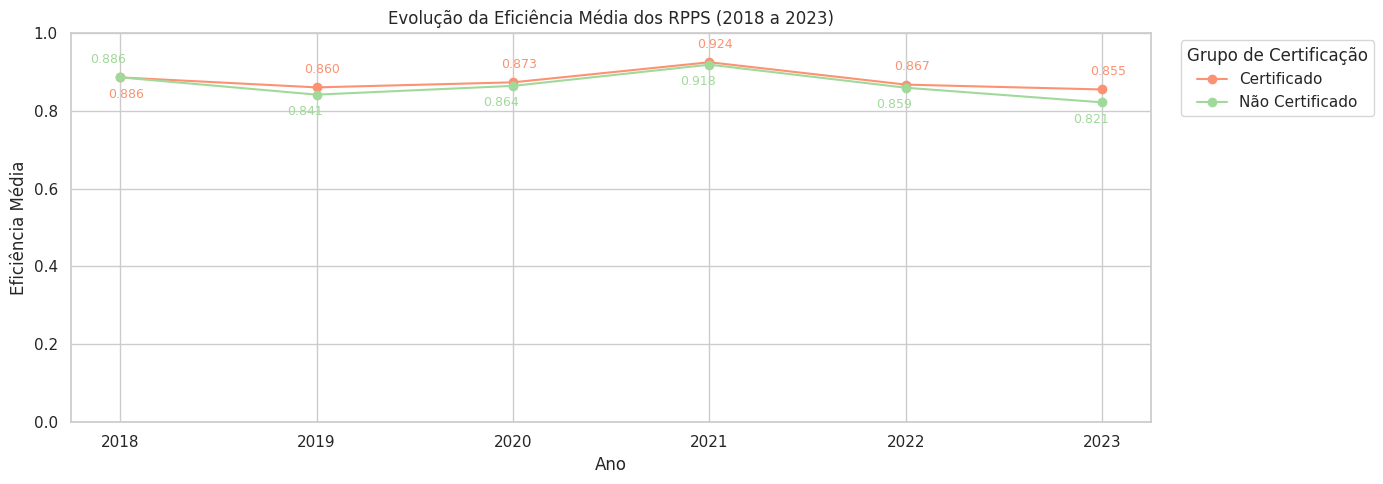

In [ ]:
# Prepara os dados para o gráfico de linha
df_linha = df_merged[df_merged['Ano'].between(2018, 2023)].copy()

# Define paleta de cores manual
palette = {
    'Certificado': '#fc9272',
    'Não Certificado': '#a1d99b'
}

plt.figure(figsize=(14, 5))

# Agrupa a média da eficiência por ano e grupo de certificação
df_grouped = df_linha.groupby(['Ano', 'grupo_certificacao'])['Eficiencia'].mean().reset_index()

# Gera a linha para cada grupo
for grupo in df_grouped['grupo_certificacao'].unique():
    dados = df_grouped[df_grouped['grupo_certificacao'] == grupo]
    plt.plot(dados['Ano'], dados['Eficiencia'], marker='o', label=grupo, color=palette[grupo])

    # Adiciona rótulos de dados com deslocamento dinâmico
    for i in range(len(dados)):
        ano_atual = dados['Ano'].iloc[i]
        valor_atual = dados['Eficiencia'].iloc[i]

        # Pega o valor do outro grupo no mesmo ano
        outro_valor = df_grouped[
            (df_grouped['Ano'] == ano_atual) &
            (df_grouped['grupo_certificacao'] != grupo)
        ]['Eficiencia']

        if not outro_valor.empty:
            # Se for maior que o outro grupo → desloca para cima
            deslocamento_y = 0.03 if valor_atual > outro_valor.iloc[0] else -0.06
        else:
            deslocamento_y = 0.03  # valor padrão se não houver comparação possível

        # Pequeno deslocamento horizontal fixo para evitar sobreposição
        deslocamento_x = 0.03 if grupo == 'Certificado' else -0.06

        plt.text(
            ano_atual + deslocamento_x,
            valor_atual + deslocamento_y,
            f"{valor_atual:.3f}",
            ha='center', va='bottom', fontsize=9, color=palette[grupo]
        )

plt.title('Evolução da Eficiência Média dos RPPS (2018 a 2023)')
plt.ylabel('Eficiência Média')
plt.xlabel('Ano')
plt.ylim(0, 1)
plt.grid(True, axis='y')

plt.legend(title='Grupo de Certificação', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


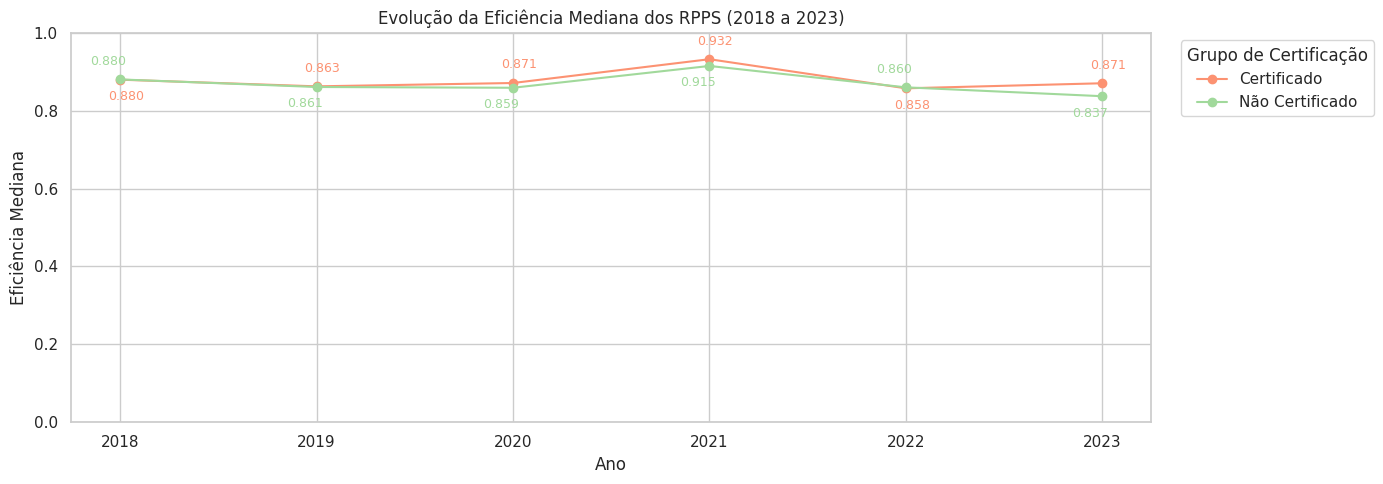

In [ ]:
# Prepara os dados para o gráfico de linha (mediana)
df_linha = df_merged[df_merged['Ano'].between(2018, 2023)].copy()

# Define paleta de cores manual
palette = {
    'Certificado': '#fc9272',
    'Não Certificado': '#a1d99b'
}

plt.figure(figsize=(14, 5))

# Agrupa a mediana da eficiência por ano e grupo de certificação
df_grouped_mediana = df_linha.groupby(['Ano', 'grupo_certificacao'])['Eficiencia'].median().reset_index()

# Gera a linha para cada grupo
for grupo in df_grouped_mediana['grupo_certificacao'].unique():
    dados = df_grouped_mediana[df_grouped_mediana['grupo_certificacao'] == grupo]
    plt.plot(dados['Ano'], dados['Eficiencia'], marker='o', label=grupo, color=palette[grupo])

    # Adiciona rótulos de dados com deslocamento dinâmico
    for i in range(len(dados)):
        ano_atual = dados['Ano'].iloc[i]
        valor_atual = dados['Eficiencia'].iloc[i]

        # Pega o valor do outro grupo no mesmo ano
        outro_valor = df_grouped_mediana[
            (df_grouped_mediana['Ano'] == ano_atual) &
            (df_grouped_mediana['grupo_certificacao'] != grupo)
        ]['Eficiencia']

        if not outro_valor.empty:
            deslocamento_y = 0.03 if valor_atual > outro_valor.iloc[0] else -0.06
        else:
            deslocamento_y = 0.03

        deslocamento_x = 0.03 if grupo == 'Certificado' else -0.06

        plt.text(
            ano_atual + deslocamento_x,
            valor_atual + deslocamento_y,
            f"{valor_atual:.3f}",
            ha='center', va='bottom', fontsize=9, color=palette[grupo]
        )

plt.title('Evolução da Eficiência Mediana dos RPPS (2018 a 2023)')
plt.ylabel('Eficiência Mediana')
plt.xlabel('Ano')
plt.ylim(0, 1)
plt.grid(True, axis='y')

plt.legend(title='Grupo de Certificação', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


,Teste,Grupo,Estatística,p-valor
0,Wilcoxon,Certificados,357.000000,0.002499
1,Wilcoxon,Não Certificados,188.000000,0.000003
2,Mann-Whitney U,Certificados vs Não Certificados,2034.000000,0.052175


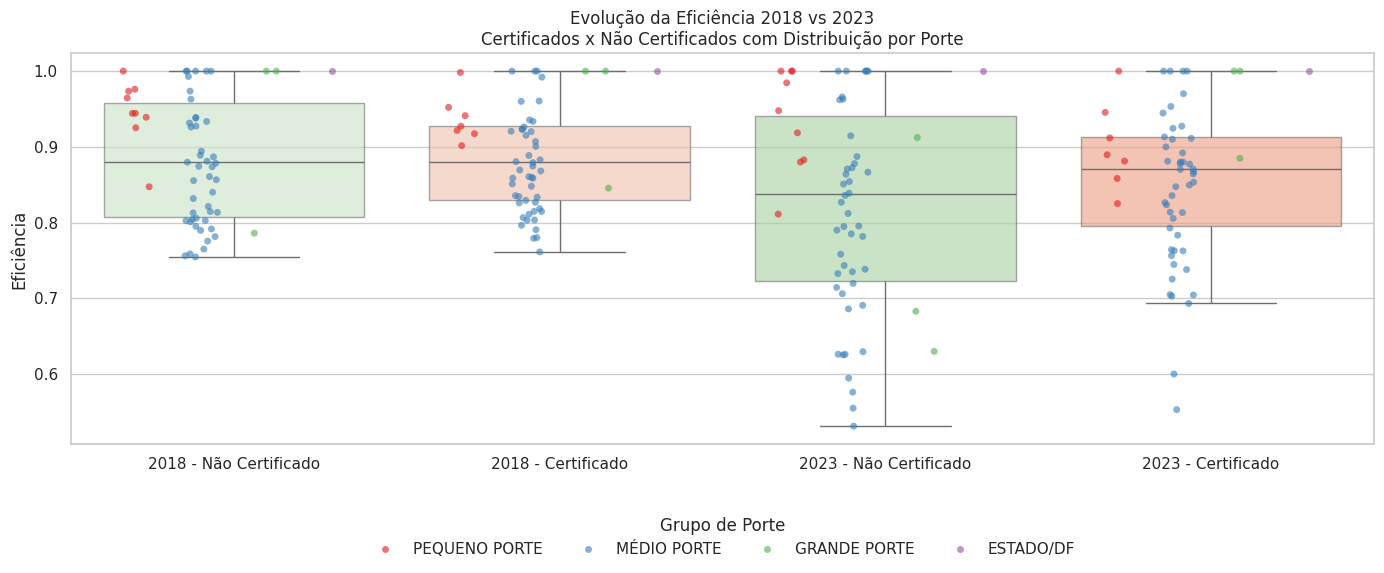

/tmp/ipython-input-2190687113.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


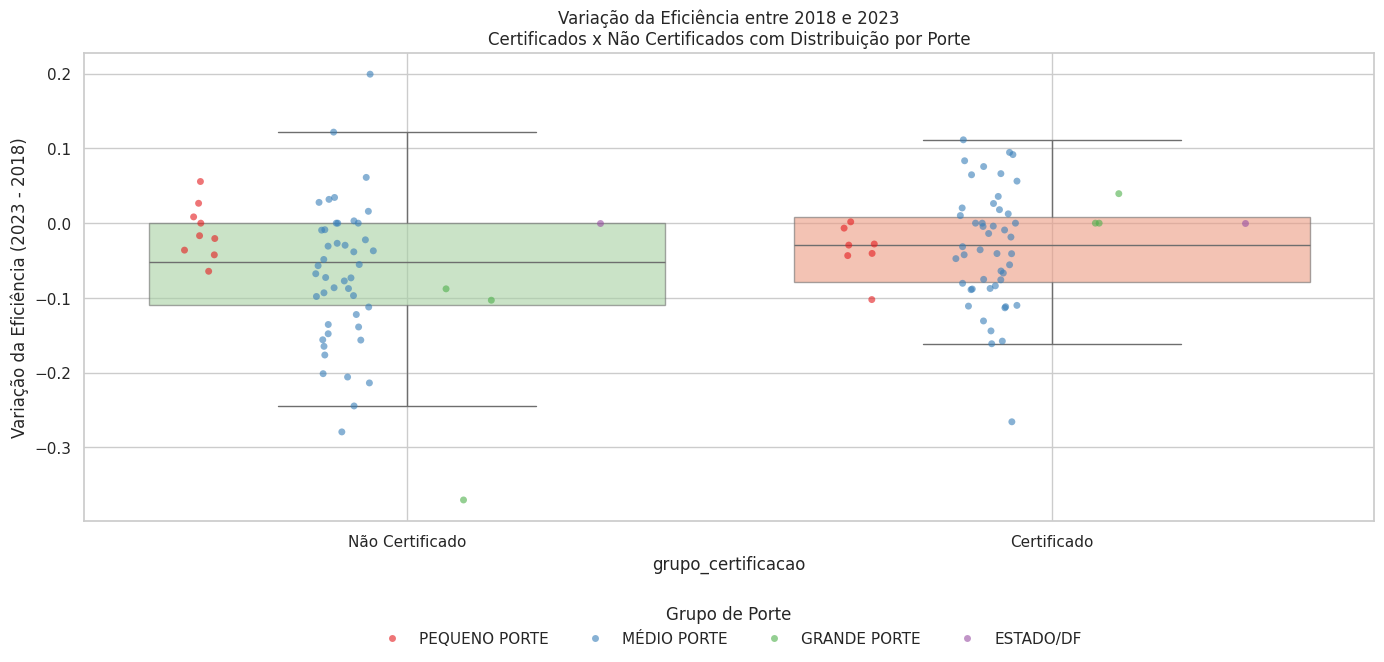

In [ ]:
# Análise estatística de comparação das eficiências em 2018 e 2023 do grupo controle e do grupo tratado

# Seleciona apenas dados de 2018 e 2023
df_comp = df_merged[df_merged['Ano'].isin([2018, 2023])].copy()
df_comp = df_comp[df_comp['Eficiencia'].notna()]

# Prepara os dados para o gráfico de comparação por ano e certificação
df_plot = df_comp.copy()
df_plot['ano_cert'] = df_plot['Ano'].astype(str) + ' - ' + df_plot['grupo_certificacao']

# Garante que só serão analisados RPPS com os dois anos disponíveis
rpps_validos = df_comp.groupby('RPPS')['Ano'].nunique()
rpps_duplos = rpps_validos[rpps_validos == 2].index
df_comp = df_comp[df_comp['RPPS'].isin(rpps_duplos)]

# Reestrutura: eficiência de 2018 e 2023 por RPPS
df_2018 = df_comp[df_comp['Ano'] == 2018][['RPPS', 'Eficiencia']].rename(columns={'Eficiencia': 'ef_2018'})
df_2023 = df_comp[df_comp['Ano'] == 2023][['RPPS', 'Eficiencia']].rename(columns={'Eficiencia': 'ef_2023'})
df_base = df_merged.drop_duplicates(subset='RPPS')[['RPPS', 'grupo', 'nivel_inicial', 'ano_cert_inicial', 'grupo_certificacao']]

# Merge tudo em um único dataframe
df_final = df_base.merge(df_2018, on='RPPS').merge(df_2023, on='RPPS')
df_final['variacao'] = df_final['ef_2023'] - df_final['ef_2018']
df_final['tendencia'] = df_final['variacao'].apply(lambda x: 'Melhorou' if x > 0 else ('Piorou' if x < 0 else 'Igual'))

# Separa os grupos
cert = df_final[df_final['grupo_certificacao'] == 'Certificado']
nao_cert = df_final[df_final['grupo_certificacao'] == 'Não Certificado']

# Executa os testes
wilcoxon_cert = wilcoxon(cert['ef_2018'], cert['ef_2023'])
wilcoxon_nao_cert = wilcoxon(nao_cert['ef_2018'], nao_cert['ef_2023'])
mann_result = mannwhitneyu(cert['variacao'], nao_cert['variacao'], alternative='two-sided')

# Monta a tabela
tabela_resultados = pd.DataFrame([
    ['Wilcoxon', 'Certificados', wilcoxon_cert.statistic, wilcoxon_cert.pvalue],
    ['Wilcoxon', 'Não Certificados', wilcoxon_nao_cert.statistic, wilcoxon_nao_cert.pvalue],
    ['Mann-Whitney U', 'Certificados vs Não Certificados', mann_result.statistic, mann_result.pvalue]
], columns=['Teste', 'Grupo', 'Estatística', 'p-valor'])

# Formatar casas decimais
tabela_resultados['Estatística'] = tabela_resultados['Estatística'].apply(lambda x: f"{x:.6f}")
tabela_resultados['p-valor'] = tabela_resultados['p-valor'].apply(lambda x: f"{x:.6f}")

# Exibe a tabela
display(HTML("<br><br><hr><br><br>"))
display(tabela_resultados)
display(HTML("<br><br><hr><br><br>"))

# Gráfico de comparação de eficiência por ano e grupo
plt.figure(figsize=(14, 6))

# Paleta manual para as caixinhas
palette_box = {
    '2018 - Não Certificado': '#c7e9c0',  # verde claro para 2018
    '2023 - Não Certificado': '#a1d99b',  # verde original para 2023
    '2018 - Certificado':     '#fcbba1',  # vermelho claro para 2018
    '2023 - Certificado':     '#fc9272'   # vermelho original para 2023
}

# Ordem fixa para que os Não Certificados apareçam primeiro
ordem_anos = [
    "2018 - Não Certificado",
    "2018 - Certificado",
    "2023 - Não Certificado",
    "2023 - Certificado"
]

# Boxplot com 2 cores, fixas para Certificado e Não Certificado
sns.boxplot(
    x='ano_cert',
    y='Eficiencia',
    data=df_plot,
    order=ordem_anos,
    hue='ano_cert',
    palette=palette_box,
    showcaps=True,
    boxprops={'alpha': 0.6},   # transparência uniforme
    showfliers=False
)

# Stripplot com bolinhas separadas pelos grupos de porte (hue apenas aqui)
ordem_portes = ["PEQUENO PORTE", "MÉDIO PORTE", "GRANDE PORTE", "ESTADO/DF"]
sns.stripplot(
    x='ano_cert',
    y='Eficiencia',
    data=df_plot,
    order=ordem_anos,
    hue='grupo',
    hue_order=ordem_portes,
    dodge=True,
    alpha=0.6,
    palette="Set1",
    jitter=0.2
)

plt.title('Evolução da Eficiência 2018 vs 2023\nCertificados x Não Certificados com Distribuição por Porte')
plt.ylabel('Eficiência')
plt.xlabel('')

# Legenda
plt.legend(title='Grupo de Porte', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


# Segundo gráfico análise da variação da eficiência
plt.figure(figsize=(14, 6))

ordem_cert = [
    "Não Certificado",
    "Certificado",
]

palette_variacao = {
    'Certificado':     '#fc9272',
    'Não Certificado': '#a1d99b'
}

sns.boxplot(
    x='grupo_certificacao',
    y='variacao',
    data=df_final,
    order=ordem_cert,
    palette=palette_variacao,
    showcaps=True,
    boxprops={'alpha': 0.6},
    showfliers=False
)

sns.stripplot(
    x='grupo_certificacao',
    y='variacao',
    data=df_final,
    order=ordem_cert,
    hue='grupo',
    hue_order=ordem_portes,
    dodge=True,
    alpha=0.6,
    palette="Set1",
    jitter=0.2,
)

plt.ylabel('Variação da Eficiência (2023 - 2018)')
plt.title('Variação da Eficiência entre 2018 e 2023\nCertificados x Não Certificados com Distribuição por Porte')
plt.grid(True)
plt.tight_layout()

plt.legend(title='Grupo de Porte', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False)


plt.show()


,Teste,Grupo,Estatística,p-valor
0,Wilcoxon,Nível I,227.0,0.002974
1,Wilcoxon,Nível II,16.0,0.496094
2,Mann-Whitney U,Nível I vs Nível II (Variação),215.5,0.249182


/tmp/ipython-input-2714475645.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


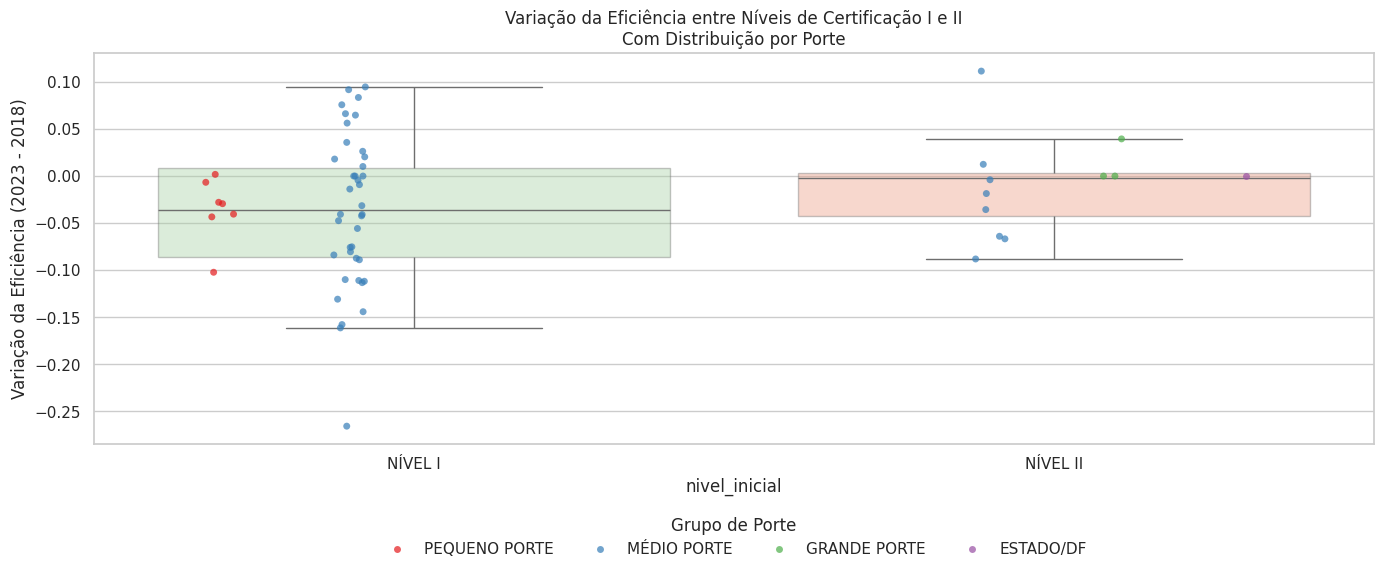

In [ ]:
# Compara resultados entre dois níveis de certificação

# Seleciona os RPPS com níveis I ou II
rpps_selecionados = df_merged[
    (df_merged['nivel_inicial'].isin(['I', 'II']))
]['RPPS'].unique()

# Filtra esses RPPS para os anos 2019 e 2023
df_comp = df_merged[
    (df_merged['RPPS'].isin(rpps_selecionados)) &
    (df_merged['Ano'].isin([2018, 2023]))
].copy()

# Garante que só serão analisados RPPS com dados nos dois anos
rpps_validos = df_comp.groupby('RPPS')['Ano'].nunique()
rpps_duplos = rpps_validos[rpps_validos == 2].index
df_comp = df_comp[df_comp['RPPS'].isin(rpps_duplos)]

# Monta base com eficiência de 2018 e 2023
df_2018 = df_comp[df_comp['Ano'] == 2018][['RPPS', 'Eficiencia', 'nivel_inicial']].rename(columns={'Eficiencia': 'ef_2018'})
df_2023 = df_comp[df_comp['Ano'] == 2023][['RPPS', 'Eficiencia']].rename(columns={'Eficiencia': 'ef_2023'})

# Merge das informações
df_final = df_2018.merge(df_2023, on='RPPS')
df_final['variacao'] = df_final['ef_2023'] - df_final['ef_2018']
df_final['tendencia'] = df_final['variacao'].apply(lambda x: 'Melhorou' if x > 0 else ('Piorou' if x < 0 else 'Igual'))

# Mapear níveis para nomes legíveis
df_final['nivel_inicial'] = df_final['nivel_inicial'].map({'I': 'NÍVEL I', 'II': 'NÍVEL II'})

# Executa os testes estatísticos
# Wilcoxon para Nível I
wilcoxon_nivel_1 = wilcoxon(
    df_final[df_final['nivel_inicial'] == 'NÍVEL I']['ef_2018'],
    df_final[df_final['nivel_inicial'] == 'NÍVEL I']['ef_2023']
)

# Wilcoxon para Nível II
wilcoxon_nivel_2 = wilcoxon(
    df_final[df_final['nivel_inicial'] == 'NÍVEL II']['ef_2018'],
    df_final[df_final['nivel_inicial'] == 'NÍVEL II']['ef_2023']
)

# Mann-Whitney entre as variações dos dois níveis
nivel_1 = df_final[df_final['nivel_inicial'] == 'NÍVEL I']['variacao']
nivel_2 = df_final[df_final['nivel_inicial'] == 'NÍVEL II']['variacao']
resultado_mw = mannwhitneyu(nivel_1, nivel_2, alternative='two-sided')

# Monta a tabela de resultados
tabela_resultados = pd.DataFrame([
    ['Wilcoxon', 'Nível I', wilcoxon_nivel_1.statistic, wilcoxon_nivel_1.pvalue],
    ['Wilcoxon', 'Nível II', wilcoxon_nivel_2.statistic, wilcoxon_nivel_2.pvalue],
    ['Mann-Whitney U', 'Nível I vs Nível II (Variação)', resultado_mw.statistic, resultado_mw.pvalue]
], columns=['Teste', 'Grupo', 'Estatística', 'p-valor'])

# Espaçamento
display(HTML("<br><br><hr><br><br>"))

# Exibe a tabela
display(tabela_resultados)

# Espaçamento
display(HTML("<br><br><hr><br><br>"))

# Gráfico de comparação da variação
# Merge incluindo o grupo
df_base = df_merged.drop_duplicates(subset='RPPS')[['RPPS', 'grupo']]
df_final = df_2018.merge(df_2023, on='RPPS').merge(df_base, on='RPPS')

df_final['variacao'] = df_final['ef_2023'] - df_final['ef_2018']
df_final['tendencia'] = df_final['variacao'].apply(lambda x: 'Melhorou' if x > 0 else ('Piorou' if x < 0 else 'Igual'))

# Mapear níveis para nomes legíveis
df_final['nivel_inicial'] = df_final['nivel_inicial'].map({'I': 'NÍVEL I', 'II': 'NÍVEL II'})

# Plot no mesmo padrão dos outros
plt.figure(figsize=(14, 6))

# Paleta fixa para os boxplots
palette_box = {
    'NÍVEL I': '#a1d99b',
    'NÍVEL II': '#fc9272'
}

# Boxplot
sns.boxplot(
    x='nivel_inicial',
    y='variacao',
    data=df_final,
    order=['NÍVEL I', 'NÍVEL II'],
    palette=palette_box,
    showcaps=True,
    boxprops={'alpha': 0.4},
    showfliers=False
)

# Stripplot com grupos de porte
sns.stripplot(
    x='nivel_inicial',
    y='variacao',
    data=df_final,
    hue='grupo',
    order=['NÍVEL I', 'NÍVEL II'],
    hue_order=['PEQUENO PORTE', 'MÉDIO PORTE', 'GRANDE PORTE', 'ESTADO/DF'],
    dodge=True,
    alpha=0.7,
    palette="Set1",
    jitter=0.1
)

plt.ylabel('Variação da Eficiência (2023 - 2018)')
plt.title('Variação da Eficiência entre Níveis de Certificação I e II\nCom Distribuição por Porte')

#  Legenda fora, à direita no topo
plt.legend(title='Grupo de Porte', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False)

plt.grid(True, axis='y')
plt.tight_layout()
plt.show()
